# GLiNER2.5 Inside neo4j-graphrag

**The package's knowledge-graph builder with the LLM taken out — GLiNER2.5 in the extractor slot, every
entity resolver the package ships measured against gold, and a resolver that keeps what they discard. No
LLM, no API key.**

[Notebook 07](07_kg_framework_comparison.ipynb) ran `SimpleKGPipeline` with Claude Haiku and closed on two
observations. The only entity resolution it ships is an exact string match. And *"to use a different
resolver you have to abandon `SimpleKGPipeline` and assemble `neo4j_graphrag.experimental.pipeline`
components yourself"*. This notebook does that, and replaces the LLM as well.

neo4j-graphrag builds a graph as a pipeline of components. Only one of them reads text with a model:

| stage | component | model |
|---|---|---|
| split | `FixedSizeSplitter` | — |
| embed chunks | `TextChunkEmbedder` + `SentenceTransformerEmbeddings` | MiniLM-L6, 22M, local |
| **extract** | **`GlinerEntityRelationExtractor`** (`kgx.graphrag`) | **GLiNER2.5-base, 194M, local** |
| prune | `GraphPruning` | — |
| write | `Neo4jWriter` | — |
| resolve | `SinglePropertyExactMatchResolver`, `FuzzyMatchResolver`, `SpaCySemanticMatchResolver`, **`KgxResolver`** | none / spaCy vectors / MiniLM |

`SimpleKGPipeline` hardwires the extract slot to `LLMEntityRelationExtractor`, but the slot itself is an
ordinary component with a published contract: `EntityRelationExtractor.run(chunks, document_info,
lexical_graph_config, schema) -> Neo4jGraph`. Anything that honours it can take the slot. GLiNER2.5 decodes
entities and relations *jointly* against a typed schema, on a laptop CPU, and nothing it does generates
text.

| § | what | the question |
|---|---|---|
| 1 | schema | can one ontology drive both GLiNER's decoding and the package's pruning? |
| 2 | extractor | does the component reproduce the repo's GLiNER extraction exactly? |
| 3 | chunking | what does the text splitter do to an encoder's recall? |
| 4 | pipeline | the whole thing, one document at a time, into Neo4j |
| 5 | resolution | what each of the package's resolvers does — including what gold labels cannot see |
| 6 | retrieval | the graph under the package's own retriever, still with no LLM |

Two things matter more than any threshold, and both are measured in §5. **The package's resolvers discard
the names they merge.** The node that survives keeps one arbitrary surface form, so the graph cannot be
queried by name, and a later run cannot see the aliases. **Scored against gold alone, they look better
than they are.** Their worst merges fall on mentions the gold set does not label.

## 0. Setup

Everything runs locally. §1–§3 need no database; §4 onward needs the Neo4j that
`scripts/neo4j_up.sh` starts, with APOC, which the package's writer and resolvers call.

Version note: neo4j-graphrag **1.19** moved the components out of `experimental`. `from
neo4j_graphrag.components...` is the current import, and the old paths still work with a
`DeprecationWarning` until 2.0. The orchestrator that wires components together has *not* moved: it is still
`neo4j_graphrag.experimental.pipeline.Pipeline`. The `neo4j_graphrag.pipeline` added in 1.20 is an
unrelated dataflow DSL, not a newer home for it.

In [1]:
import os, sys, time, warnings, logging, collections
from importlib.metadata import version
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("neo4j").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

import kgx
from kgx.data.documents import DOCUMENTS, ALIAS_GROUPS, GOLD_DOC_FACTS
from kgx.evaluate import MatchPolicy, score_triples
from kgx.graphrag import (
    PARTITION_FILTER, GlinerEntityRelationExtractor, KgxResolver, MentionLayer,
    TransitiveFuzzyMatchResolver, attach_mentions, clear_partition, consolidate_transitively,
    graph_schema, joint_schema, model_name, read_clusters, relation_options,
)
from neo4j_graphrag.experimental.pipeline import Pipeline
from neo4j_graphrag.components.text_splitters.fixed_size_splitter import FixedSizeSplitter
from neo4j_graphrag.components.embedder import TextChunkEmbedder
from neo4j_graphrag.components.graph_pruning import GraphPruning
from neo4j_graphrag.components.kg_writer import Neo4jWriter
from neo4j_graphrag.components.resolver import (
    BasePropertySimilarityResolver, FuzzyMatchResolver,
    SinglePropertyExactMatchResolver, SpaCySemanticMatchResolver,
)
from neo4j_graphrag.components.types import DocumentInfo, Neo4jGraph
from neo4j_graphrag.embeddings import SentenceTransformerEmbeddings

ONTOLOGY = kgx.BUSINESS_NEWS
LEXICAL_LABELS = {"Document", "Chunk"}
LEXICAL_TYPES = {"FROM_CHUNK", "FROM_DOCUMENT", "NEXT_CHUNK"}

for pkg in ("neo4j-graphrag", "gliner2", "neo4j", "spacy"):
    print(f"{pkg:16}{version(pkg)}")
print(f"\ncorpus          {len(DOCUMENTS)} documents, {sum(len(d['text'].split()) for d in DOCUMENTS):,} words")
print(f"gold            {len(ALIAS_GROUPS)} alias groups (resolution), {len(GOLD_DOC_FACTS)} triples (extraction)")

neo4j-graphrag  1.21.0
gliner2         2.0.0
neo4j           6.2.0
spacy           3.8.16

corpus          10 documents, 2,284 words
gold            13 alias groups (resolution), 47 triples (extraction)


In [2]:
# Figures: static PNGs on a light chart surface. Identity takes at most three categorical hues
# (blue, orange, aqua -- validated all-pairs for colour-vision deficiency) plus gray for context;
# aqua is below 3:1 contrast on the surface, so every aqua mark carries a text label.
import re
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
%config InlineBackend.figure_format = "retina"

SURFACE, INK, INK2, MUTED, GRID, BASE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
TYPE_COLOR = {"Company": BLUE, "Person": ORANGE, "Regulator": AQUA}     # every other type: gray
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 9, "text.color": INK, "axes.labelcolor": INK2,
    "axes.edgecolor": BASE, "axes.linewidth": 0.8, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlesize": 10, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "legend.frameon": False,
})

def tint(color, amount=0.22):
    # `color` washed over the surface, for diagram boxes
    c = [int(color[i:i + 2], 16) for i in (1, 3, 5)]
    b = [int(SURFACE[i:i + 2], 16) for i in (1, 3, 5)]
    return "#" + "".join(f"{round(amount * x + (1 - amount) * y):02x}" for x, y in zip(c, b))

def box(ax, x, y, text, *, w=1.7, h=0.62, fill="#f0efec", size=8.5, weight="normal"):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, fc=fill, ec="none",
                                boxstyle="round,pad=0,rounding_size=0.08"))
    ax.text(x, y, text, ha="center", va="center", fontsize=size, fontweight=weight, linespacing=1.35)

def arrow(ax, a, b, text="", *, color=MUTED, rad=0.0, lw=1.2, offset=(0, 0.06), size=7.5, ha="center"):
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=9, color=color, lw=lw,
                                 connectionstyle=f"arc3,rad={rad}", shrinkA=0, shrinkB=0))
    if text:
        ax.text((a[0] + b[0]) / 2 + offset[0], (a[1] + b[1]) / 2 + offset[1], text, ha=ha,
                va="bottom", fontsize=size, color=INK2)

def canvas(width, height, xlim, ylim):
    fig, ax = plt.subplots(figsize=(width, height))
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.axis("off")
    return fig, ax

def type_color(label):
    return TYPE_COLOR.get(label, BASE)

def type_legend(where, **kwargs):
    handles = [plt.Line2D([], [], marker="o", ls="", ms=7, mfc=c, mec=SURFACE, label=l)
               for l, c in [*TYPE_COLOR.items(), ("other types", BASE)]]
    return where.legend(handles=handles, fontsize=8, **kwargs)

In [3]:
gliner = kgx.GlinerExtractor()                          # fastino/gliner2.5-base-v1
embedder = SentenceTransformerEmbeddings("all-MiniLM-L6-v2")
print(gliner)
print(f"MiniLM: {len(embedder.embed_query('dimension probe'))} dimensions")

<GlinerExtractor fastino/gliner2.5-base-v1 194M params loaded in 4.0s>
MiniLM: 384 dimensions


## 1. One ontology, two compilations

The package describes a graph with a `GraphSchema`: node types, relationship types, and patterns — the legal
`(head, RELATIONSHIP, tail)` triples. `SimpleKGPipeline` serialises it into a prompt and prunes whatever the
LLM returns outside it. GLiNER needs the same information as a `JointSchema`, a *decoding constraint*: an
edge whose endpoint types the schema does not allow is never a candidate.

`kgx.graphrag.graph_schema` compiles the repo's `BUSINESS_NEWS` ontology into a `GraphSchema`. The extractor
compiles that `GraphSchema` into a `JointSchema` whenever the pipeline hands it one. So the pipeline's own
schema is the single source of truth, and the component works for any `GraphSchema`, not only this repo's.

In [4]:
schema = graph_schema(ONTOLOGY)
print(f"GraphSchema: {len(schema.node_types)} node types, {len(schema.relationship_types)} relationship "
      f"types, {len(schema.patterns)} patterns")

js, node_label_for, rel_type_for = joint_schema(schema, options=relation_options(ONTOLOGY),
                                                engine=gliner.joint)
pd.DataFrame(
    [{"kind": "node", "in Neo4j": nt.label, "what GLiNER reads": model_name(nt.label),
      "description": nt.description} for nt in schema.node_types[:4]]
    + [{"kind": "relationship", "in Neo4j": rt.label, "what GLiNER reads": model_name(rt.label),
        "description": rt.description} for rt in schema.relationship_types[:4]]
)

GraphSchema: 13 node types, 15 relationship types, 52 patterns


,kind,in Neo4j,what GLiNER reads,description
0,node,Company,company,"A commercial issuer or private firm, referred to by name."
1,node,Person,person,"An executive, director, founder, analyst, or named official."
2,node,Regulator,regulator,"A government body, agency, central bank, or court."
3,node,Product,product,"A named product, service, or platform."
4,relationship,SUBSIDIARY_OF,subsidiary_of,The head company is owned or controlled by the tail company.
5,relationship,OFFICER_OF,officer_of,The person holds an executive or board position at the organization.
6,relationship,ACQUIRES,acquires,The head company is buying or has bought the tail.
7,relationship,HAS_STAKE_IN,has_stake_in,The head holds an ownership interest in the tail.


GLiNER encodes the type names into its input beside the text, so a type name is part of the prompt.
`PascalCase` and `UPPER_SNAKE` are graph conventions, not how anyone writes a concept, so `model_name` turns
`BusinessSegment` back into `business_segment` and `REPORTS_METRIC` into `reports_metric` — the names the
ontology was written in — and maps the model's answers back.

A relationship's head and tail types come from the schema's patterns. GLiNER allows every head type with
every tail type, so a pattern set that is not a full cross product per relationship would be looser in
decoding than in the schema, and `GraphPruning` would enforce the difference. `BUSINESS_NEWS` is a full cross
product by construction.

Some constraints have no field in a `GraphSchema` at all. It can say which endpoints are legal, but not that a
company has one parent. `relation_options` carries those beside the schema:

In [5]:
pd.DataFrame([{"relationship": rel, **opts} for rel, opts in relation_options(ONTOLOGY).items()]).fillna("")

,relationship,unique_head,acyclic
0,SUBSIDIARY_OF,True,True
1,OFFICER_OF,True,
2,ACQUIRES,,True
3,IMPACTS,,True


## 2. The extractor as a component

`GlinerEntityRelationExtractor` subclasses the package's `EntityRelationExtractor` and returns what
`LLMEntityRelationExtractor` returns: a `Neo4jGraph` whose node ids are prefixed with the chunk id (the base
class's `update_ids`), plus the lexical graph — a `Document` node, a `Chunk` per chunk, and `FROM_CHUNK` from
every entity to the chunk it came from, built by the package's own `LexicalGraphBuilder`. Every chunk of a
document goes through GLiNER in one batched forward pass.

A component is an ordinary object with an async `run`. The pipeline calls it for you, but nothing stops you
calling it by hand, which is how this section tests it.

In [6]:
extractor = GlinerEntityRelationExtractor(gliner, relation_options=relation_options(ONTOLOGY))
splitter = FixedSizeSplitter(chunk_size=2500, chunk_overlap=200, approximate=True)

doc = DOCUMENTS[0]
chunks = await splitter.run(text=doc["text"])
graph = await extractor.run(chunks=chunks, schema=schema,
                            document_info=DocumentInfo(path=doc["doc_id"], metadata={"title": doc["title"]}))

by_id = {n.id: n for n in graph.nodes}
print(f"{doc['doc_id']}: {len(chunks.chunks)} chunk, {len(graph.nodes)} nodes, {len(graph.relationships)} "
      f"relationships in {extractor.last_timing['seconds']:.2f}s")
print("nodes by label:", dict(collections.Counter(n.label for n in graph.nodes).most_common()))
print("relationships: ", dict(collections.Counter(r.type for r in graph.relationships).most_common()))
print("\na node:", graph.nodes[2].model_dump(exclude={"embedding_properties"}))
pd.DataFrame([
    {"head": by_id[r.start_node_id].properties["name"], "type": r.type,
     "tail": by_id[r.end_node_id].properties["name"], **r.properties}
    for r in graph.relationships if r.type not in LEXICAL_TYPES
]).sort_values("confidence", ascending=False).head(8)

d01: 1 chunk, 24 nodes, 58 relationships in 1.14s
nodes by label: {'Company': 6, 'BusinessEvent': 4, 'FinancialMetric': 4, 'Geography': 2, 'Security': 2, 'Person': 2, 'Document': 1, 'Chunk': 1, 'Sector': 1, 'Regulator': 1}
relationships:  {'FROM_CHUNK': 22, 'PARTICIPANT_IN': 15, 'PARTNERS_WITH': 6, 'COMPETES_WITH': 4, 'ACQUIRES': 2, 'OFFICER_OF': 2, 'OPERATES_IN': 2, 'REPORTS_METRIC': 2, 'SUBSIDIARY_OF': 2, 'FROM_DOCUMENT': 1}

a node: {'id': 'cd21d722-9e8f-4ba4-b032-9449971803f6:e1', 'label': 'Geography', 'properties': {'name': 'SEATTLE', 'confidence': 0.7681, 'start': 0, 'end': 7}}


,head,type,tail,confidence,derived
8,Cascade Freight Systems,OPERATES_IN,Pacific Northwest,0.9522,False
0,Northwind Logistics Inc.,ACQUIRES,Cascade Freight Systems,0.9431,False
9,Cascade Freight Systems,OPERATES_IN,Pacific Northwest,0.9410,False
31,Cascade Freight Systems,REPORTS_METRIC,revenue,0.9393,False
32,Cascade Freight Systems,REPORTS_METRIC,revenue,0.9391,False
1,Northwind Logistics Inc.,ACQUIRES,Cascade Freight Systems,0.9275,False
34,Cascade Freight Systems,SUBSIDIARY_OF,Northwind Logistics,0.8906,False
33,Cascade Freight Systems,SUBSIDIARY_OF,Northwind Logistics,0.8832,False


The same extraction on the text itself. Every span GLiNER typed is highlighted, with the three types the
gold labels cover in colour and the other ten in gray. `SEATTLE` and the `Pacific Northwest` are places,
*cash* and *stock* are securities, `$28.50 per share` and *revenue* are metrics, and *agreement* and
*acquisition* are business events. The ontology asks for all of it, which is why the graph has far more nodes
than the gold set has entities. What is *not* highlighted matters too: `NWL`, inside `(NASDAQ: NWL)`, is not
extracted in this document at all.

In [7]:
from IPython.display import HTML
from spacy import displacy

cut = chunks.chunks[0].text.index("\n\n", 900)          # the first three paragraphs
spans, last_end = [], -1
for n in sorted((n for n in graph.nodes if n.label not in LEXICAL_LABELS), key=lambda n: n.properties["start"]):
    if n.properties["start"] >= last_end and n.properties["end"] <= cut:   # displaCy wants no overlaps
        spans.append({"start": n.properties["start"], "end": n.properties["end"], "label": n.label})
        last_end = n.properties["end"]
colors = {nt.label: tint(TYPE_COLOR.get(nt.label, MUTED), 0.35 if nt.label in TYPE_COLOR else 0.18)
          for nt in schema.node_types}
markup = displacy.render({"text": chunks.chunks[0].text[:cut], "ents": spans, "title": None},
                         style="ent", manual=True, jupyter=False, options={"colors": colors})
HTML(f'<div style="background:{SURFACE}; color:{INK}; padding:10px 16px; border-radius:8px">{markup}</div>')

### Is it the same extraction?

Notebook 01 extracted this corpus with `kgx.GlinerExtractor`, straight from the `Ontology`. The component
takes a detour through `GraphSchema` and back. The detour should cost nothing: same spans, same relations.

In [8]:
reference = gliner.extract_batch(DOCUMENTS, ONTOLOGY)
rows, component_graphs = [], {}
for d, ref in zip(DOCUMENTS, reference):
    ch = await splitter.run(text=d["text"])
    g = await extractor.run(chunks=ch, schema=schema, document_info=DocumentInfo(path=d["doc_id"]))
    component_graphs[d["doc_id"]] = g
    ents = [n for n in g.nodes if n.label not in LEXICAL_LABELS]
    rels = [r for r in g.relationships if r.type not in LEXICAL_TYPES]
    rows.append({
        "doc": d["doc_id"], "chunks": len(ch.chunks),
        "mentions (component)": len(ents), "mentions (kgx)": len(ref.mentions),
        "relations (component)": len(rels), "relations (kgx)": len(ref.edges),
        "identical spans": sorted((n.properties["name"], n.properties["start"]) for n in ents)
                           == sorted((m.text, m.start) for m in ref.mentions),
    })
eq = pd.DataFrame(rows).set_index("doc")
display(eq)
print(f"totals: {eq['mentions (component)'].sum()} mentions, {eq['relations (component)'].sum()} relations; "
      f"identical on {int(eq['identical spans'].sum())}/{len(eq)} documents")

,chunks,mentions (component),mentions (kgx),relations (component),relations (kgx),identical spans
doc,,,,,,
d01,1,22,22,35,35,True
d02,1,19,19,8,8,True
d03,1,15,15,5,5,True
d04,1,23,23,17,17,True
d05,1,22,22,22,22,True
d06,1,26,26,15,15,True
d07,1,16,16,12,12,True
d08,1,25,25,37,37,True
d09,1,22,22,10,10,True


totals: 214 mentions, 170 relations; identical on 10/10 documents


Identical on every document: 214 mentions and 170 relations, the numbers notebook 01 reports. The rest of
this notebook starts from the same extraction the repo has used since notebook 01. Any difference from here
on belongs to the package's machinery, not to the model.

### What the pruner does with it

`GraphPruning` drops nodes, relationships and properties the schema does not allow. After an LLM extractor it
has real work to do — notebook 07 calls schema enforcement in all three frameworks *"a post-filter"*. After
joint decoding it should have none.

In [9]:
pruner = GraphPruning()
everything = Neo4jGraph(nodes=[n for g in component_graphs.values() for n in g.nodes],
                        relationships=[r for g in component_graphs.values() for r in g.relationships])

def pruned(result):
    s = result.pruning_stats
    return {"nodes": len(s.pruned_nodes), "relationships": len(s.pruned_relationships),
            "properties": len(s.pruned_properties)}

print("pruned with graph_schema(ONTOLOGY):", pruned(await pruner.run(graph=everything, schema=schema)))

# The schema notebook 07 gave SimpleKGPipeline: every node type declares `name` and nothing else.
name_only = graph_schema(ONTOLOGY, node_properties=[{"name": "name", "type": "STRING"}])
result = await pruner.run(graph=everything, schema=name_only)
print("pruned with a name-only schema:     ", pruned(result))
print("   which properties:", dict(collections.Counter(p.item for p in result.pruning_stats.pruned_properties)))
kept = next(n for n in result.graph.nodes if n.label == "Company")
print("   a Company node after pruning:", kept.properties)

pruned with graph_schema(ONTOLOGY): {'nodes': 0, 'relationships': 0, 'properties': 0}
pruned with a name-only schema:      {'nodes': 0, 'relationships': 0, 'properties': 642}
   which properties: {'confidence': 214, 'start': 214, 'end': 214}
   a Company node after pruning: {'name': 'Northwind Logistics Inc.'}


Nothing is pruned: zero nodes and zero relationships out of 214 and 170. Joint decoding cannot produce an
edge the schema forbids, so the pruner is a no-op here, where after an LLM it is the enforcement.

The second line is a trap worth knowing before it costs you a debugging session. **A node type that declares
any properties defaults to `additional_properties=False`**, and the pruner then removes every property it
was not told about — here `confidence`, `start` and `end` from all 214 nodes. It logs this at DEBUG and
nowhere else. `graph_schema` declares all four properties the extractor writes (`kgx.graphrag.NODE_PROPERTIES`).
Any custom extractor that writes properties has to be paired with a schema that declares them.

## 3. The splitter is now the context window

With an LLM extractor, chunk size trades cost against context. With GLiNER it decides what the model can see
at all: a relation survives only if both endpoints land in the same chunk, and notebook 01 measured
relation recall falling off sharply past about 400 words of input.

`FixedSizeSplitter` counts *characters*. Its default `chunk_size=4000` is 550–650 words of English — past that
cliff. The ten documents here are 1,300–2,200 characters each, so the default never splits them. Two sweeps:
the ten documents at smaller chunk sizes, then the whole corpus as one 2,284-word document, where the default
does bite. Recall is scored against the 47 gold triples on the extracted surface forms before any resolution,
with the gold alias table crediting name variants.

In [10]:
CHUNK_STATS = []                                         # one row per chunk, for the figure below

async def extract_all(texts, splitter, tag):
    # (chunks, words per chunk, mentions, relations, distinct surface triples, long-chunk warnings)
    n_chunks, words, mentions, rels, triples, n_warn = 0, [], 0, 0, set(), 0
    for text in texts:
        ch = await splitter.run(text=text)
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            g = await extractor.run(chunks=ch, schema=schema)
        n_warn += sum("words" in str(w.message) for w in caught)
        n_chunks += len(ch.chunks)
        words += [len(c.text.split()) for c in ch.chunks]
        nodes = {n.id: n for n in g.nodes}
        mentions += sum(n.label not in LEXICAL_LABELS for n in g.nodes)
        for c in ch.chunks:
            prefix = c.chunk_id + ":"                    # entity ids are chunk-prefixed
            CHUNK_STATS.append({
                "input": tag, "words": len(c.text.split()),
                "mentions": sum(n.id.startswith(prefix) for n in g.nodes),
                "relations": sum(r.start_node_id.startswith(prefix) for r in g.relationships
                                 if r.type not in LEXICAL_TYPES)})
        for r in g.relationships:
            if r.type not in LEXICAL_TYPES:
                rels += 1
                triples.add((nodes[r.start_node_id].properties["name"], model_name(r.type),
                             nodes[r.end_node_id].properties["name"]))
    s = score_triples(sorted(triples), GOLD_DOC_FACTS, aliases=ALIAS_GROUPS)
    return {"chunks": n_chunks, "words/chunk": f"{min(words)}-{max(words)}", "mentions": mentions,
            "relations": rels, "gold recall": round(s.recall, 3), "precision": round(s.precision, 3),
            "long-chunk warnings": n_warn}

texts = [d["text"] for d in DOCUMENTS]
sweep = {f"{size} / {overlap}": await extract_all(texts, FixedSizeSplitter(chunk_size=size, chunk_overlap=overlap,
                                                                             approximate=True), "ten documents")
         for size, overlap in [(4000, 200), (1000, 100), (600, 100), (400, 50)]}
display(pd.DataFrame(sweep).T.rename_axis("ten documents: chunk_size / overlap"))

corpus = "\n\n".join(texts)
sweep = {f"{size} / 200": await extract_all([corpus], FixedSizeSplitter(chunk_size=size, chunk_overlap=200,
                                                                        approximate=True), "one long document")
         for size in (4000, 2500, 1500)}
display(pd.DataFrame(sweep).T.rename_axis("one 2,284-word document"))

,chunks,words/chunk,mentions,relations,gold recall,precision,long-chunk warnings
ten documents: chunk_size / overlap,,,,,,,
4000 / 200,10,200-339,214,170,0.404,0.2,0
1000 / 100,21,59-161,275,181,0.426,0.167,0
600 / 100,32,30-98,319,191,0.362,0.125,0
400 / 50,46,12-69,340,174,0.255,0.092,0


,chunks,words/chunk,mentions,relations,gold recall,precision,long-chunk warnings
"one 2,284-word document",,,,,,,
4000 / 200,4,560-610,115,159,0.34,0.333,4
2500 / 200,7,195-391,180,167,0.404,0.302,0
1500 / 200,12,119-235,253,245,0.426,0.189,0


In [11]:
# The two obvious suspects for the missing mentions on 600-word chunks: truncation, and a cap on candidates.
from gliner2.joint_ie import JointIEConfig

long_chunks = await FixedSizeSplitter(chunk_size=4000, chunk_overlap=200, approximate=True).run(text=corpus)
rows = []
for k in (32, 128):                                     # 32 is JointIEConfig's default
    probe = GlinerEntityRelationExtractor(gliner, relation_options=relation_options(ONTOLOGY),
                                          config=JointIEConfig(top_k_entities=k), warn_words=10_000)
    g = await probe.run(chunks=long_chunks, schema=schema)
    for c in long_chunks.chunks:
        ends = [n.properties["end"] for n in g.nodes if n.id.startswith(c.chunk_id + ":")]
        rows.append({"top_k_entities": k, "chunk": c.index, "words": len(c.text.split()),
                     "mentions": len(ends), "last mention ends at word": len(c.text[:max(ends)].split())})
pd.DataFrame(rows).set_index(["top_k_entities", "chunk"])

words  mentions  last mention ends at word
top_k_entities chunk                                            
32             0        602        28                        589
               1        610        29                        578
               2        598        29                        591
               3        560        29                        534
128            0        602        28                        589
               1        610        29                        578
               2        598        29                        591
               3        560        29                        534

Every chunk from both sweeps as a point: how many mentions GLiNER found per hundred words, against how
long the chunk was.

findfont: Failed to find font weight semibold, now using 700.


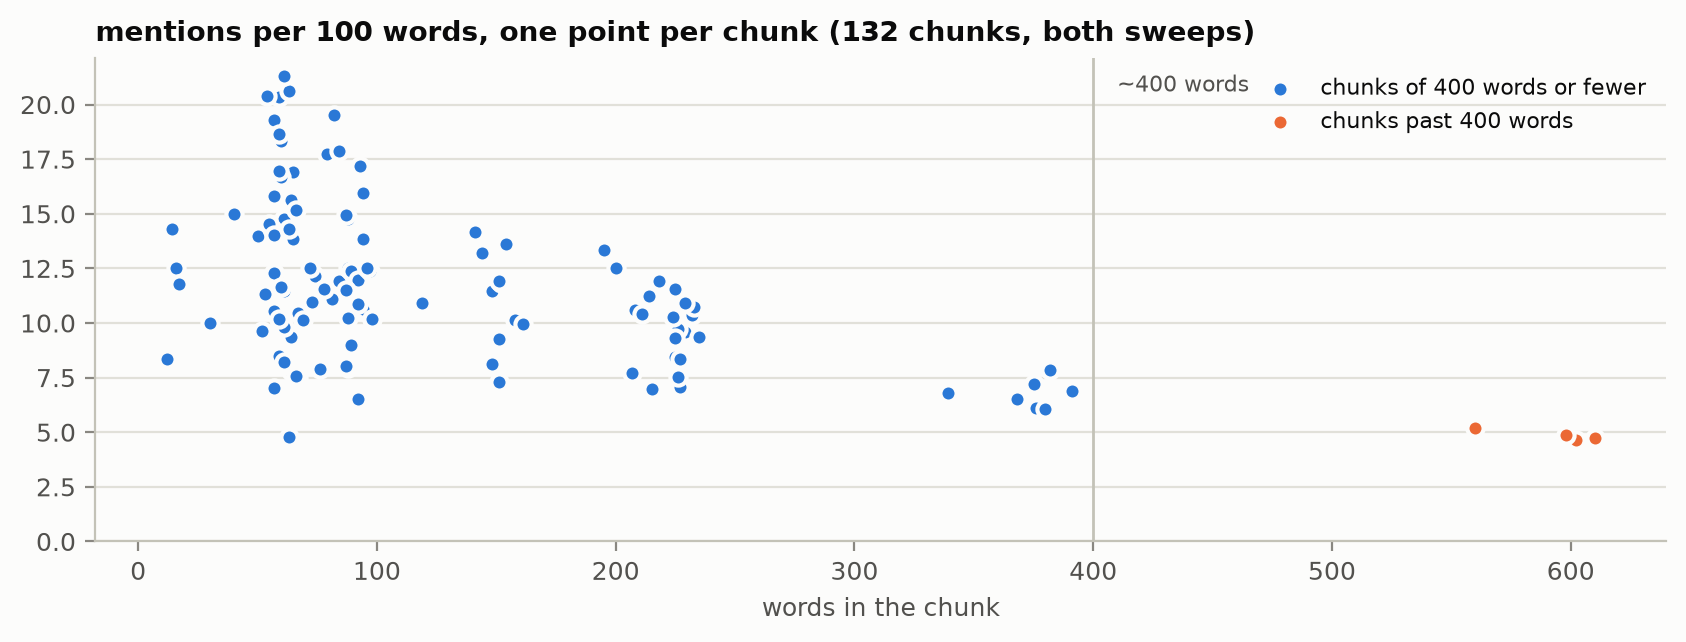

In [12]:
cs = pd.DataFrame(CHUNK_STATS)
cs["mentions per 100 words"] = 100 * cs["mentions"] / cs["words"]
past = cs["words"] > 400
fig, ax = plt.subplots(figsize=(8.5, 3.3))
for mask, color, label in ((~past, BLUE, "chunks of 400 words or fewer"), (past, ORANGE, "chunks past 400 words")):
    ax.scatter(cs.loc[mask, "words"], cs.loc[mask, "mentions per 100 words"], s=34, color=color,
               edgecolor=SURFACE, linewidth=1.5, zorder=3, label=label)
ax.axvline(400, color=BASE, lw=1, zorder=1)
ax.set_ylim(bottom=0)
ax.text(410, ax.get_ylim()[1] * 0.93, "~400 words", color=INK2, fontsize=8)
ax.grid(axis="y"); ax.set_axisbelow(True)
ax.set_xlabel("words in the chunk")
ax.set_title(f"mentions per 100 words, one point per chunk ({len(cs)} chunks, both sweeps)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()

Read the two tables separately.

**On the ten documents, smaller chunks do not pay.** Every document fits in one chunk at the default.
1,000-character chunks find one more gold triple (recall 0.426 against 0.404) and lose precision for it
(0.200 to 0.167). Below that, cutting loses the relations that cross a chunk boundary: 400 characters falls
to 0.255 recall. Overlap inflates the mention count as well — 214 becomes 340 — because every span in an
overlap is extracted twice. Those duplicates are exactly what resolution has to merge.

**On the long document, the default is the worst setting.** Chunks of 560–610 words cost relation recall
(0.340 against 0.404) and, less expectedly, *mentions*: 115 spans where 2,500-character chunks find 180.
The scatter shows the shape of it: the four orange chunks, the default's 560–610 words, sit at the bottom,
below every chunk under 400 words. The last table rules out the two obvious suspects. It is not truncation: the last mention in each
4,000-character chunk sits within a few dozen words of its end. And it is not the candidate cap:
`JointIEConfig(top_k_entities=128)` finds exactly what the default 32 does. It is simply what the encoder
does with long inputs, and the component's warning (`long-chunk warnings`) is how you find out.

The rule this gives: **size chunks in words, below ~400, and as large as that allows.** The pipeline below
uses 2,500 characters with 200 of overlap. Every document here stays whole, and a longer one would be cut
before the cliff.

## 4. The pipeline

Now the real thing: the package's `Pipeline`, with the components wired the way `SimpleKGPipeline` wires its
own (`_get_connections` in `simple_kg_builder.py`), plus two changes. The extractor is GLiNER. The resolver is
`KgxResolver`, which §5 argues for, preceded by `MentionLayer`, which §5 explains.

The database is shared. Notebook 02's graph and notebook 15's live in it too, and the package's resolvers
consider **every `:__Entity__` node in the database** unless told otherwise. So everything here is scoped by
the `__KGBuilder__` label, which the package's writer puts on every node it creates and nothing else in this
repo writes. Resolvers get `filter_query=PARTITION_FILTER` (`WHERE entity:__KGBuilder__`), and re-running
the notebook clears only that partition.

In [13]:
from kgx.neo4j_io import Neo4jConfig, connect, has_apoc

config = Neo4jConfig.from_env(uri=os.environ.get("NEO4J_URI", "bolt://localhost:7690"),
                              user=os.environ.get("NEO4J_USER", "neo4j"),
                              password=os.environ.get("NEO4J_PASSWORD", "sandbox-kg"))
if "driver" in globals():
    driver.close()
driver = connect(config, notifications="OFF")     # fails loudly: §4 onward needs the database
assert has_apoc(driver), "the package's writer and resolvers call APOC; scripts/neo4j_up.sh installs it"

def q(query, **params):
    return [dict(r) for r in driver.execute_query(query, params, database_=config.database).records]

print(f"connected to {config.uri}; cleared {clear_partition(driver)} nodes from a previous run of this notebook")
outside = q("MATCH (e:__Entity__) WHERE NOT e:__KGBuilder__ RETURN count(e) AS n")[0]["n"]
print(f"{outside} :__Entity__ nodes from other notebooks share this database — out of scope for every resolver below")

connected to bolt://localhost:7690; cleared 343 nodes from a previous run of this notebook
212 :__Entity__ nodes from other notebooks share this database — out of scope for every resolver below


In [14]:
shared_resolver = kgx.EntityResolver(threshold=0.90)   # kgx's resolver; MiniLM loads once, here
shared_resolver.encoder

pipe = Pipeline()
pipe.add_component(splitter, "splitter")
pipe.add_component(TextChunkEmbedder(embedder), "chunk_embedder")
pipe.add_component(extractor, "extractor")
pipe.add_component(GraphPruning(), "pruner")
pipe.add_component(Neo4jWriter(driver, neo4j_database=config.database), "writer")
pipe.add_component(MentionLayer(driver, neo4j_database=config.database), "mentions")
pipe.add_component(KgxResolver(driver, filter_query=PARTITION_FILTER, resolver=shared_resolver,
                               neo4j_database=config.database), "resolver")

pipe.connect("splitter", "chunk_embedder", input_config={"text_chunks": "splitter"})
pipe.connect("chunk_embedder", "extractor", input_config={"chunks": "chunk_embedder"})
pipe.connect("extractor", "pruner", input_config={"graph": "extractor"})
pipe.connect("pruner", "writer", input_config={"graph": "pruner.graph"})
pipe.connect("writer", "mentions", input_config={})
pipe.connect("mentions", "resolver", input_config={})

frontier = [n.name for n in pipe.roots()]
while frontier:
    for edge in pipe.next_edges(frontier.pop(0)):
        print(f"  {edge.start:15} -> {edge.end:15} {edge.data.get('input_config') or '(ordering only)'}")
        frontier.append(edge.end)

  splitter        -> chunk_embedder  {'text_chunks': 'splitter'}
  chunk_embedder  -> extractor       {'chunks': 'chunk_embedder'}
  extractor       -> pruner          {'graph': 'extractor'}
  pruner          -> writer          {'graph': 'pruner.graph'}
  writer          -> mentions        (ordering only)
  mentions        -> resolver        (ordering only)


The same definition as a picture, drawn by walking `pipe` itself. Each arrow is labelled with the
parameter the next component receives. Blue boxes are this repo's components and gray boxes the
package's own; the three run-time inputs enter from above.

findfont: Failed to find font weight semibold, now using 700.


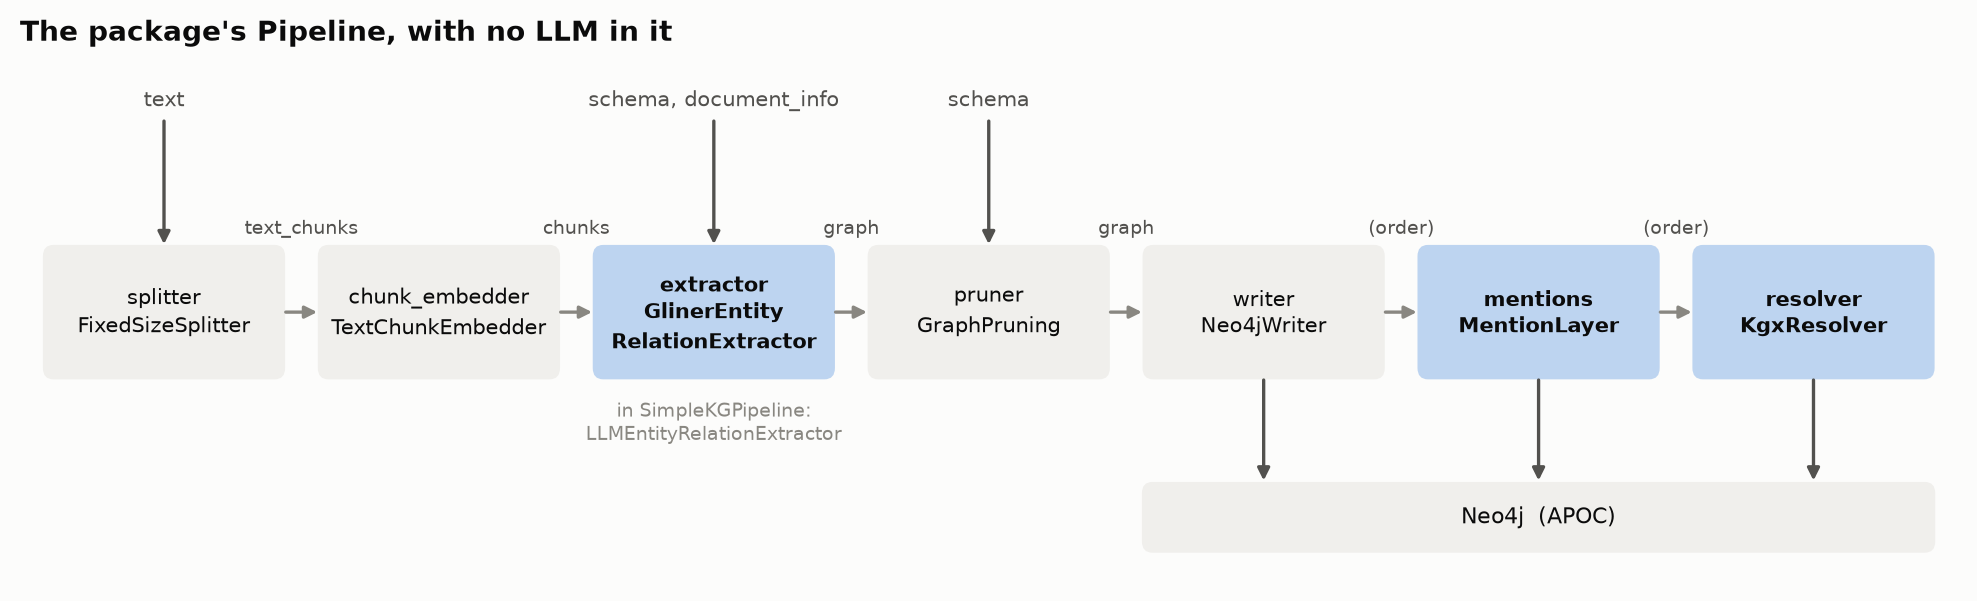

In [15]:
order = [n.name for n in pipe.roots()]
while (nxt := pipe.next_edges(order[-1])):
    order.append(nxt[0].end)
x = {name: 2.1 * i for i, name in enumerate(order)}
fig, ax = canvas(12.5, 3.4, (-1.1, x[order[-1]] + 1.1), (-1.9, 1.8))
for name in order:
    component = pipe.get_node_by_name(name).component
    ours = type(component).__module__.startswith("kgx")
    words = re.findall("[A-Z][a-z0-9]*", type(component).__name__)
    cls = "".join(words) if len(words) < 4 else "".join(words[:2]) + "\n" + "".join(words[2:])
    box(ax, x[name], 0, f"{name}\n{cls}", w=1.85, h=0.95, size=7.5,
        fill=tint(BLUE, 0.3) if ours else "#f0efec", weight="semibold" if ours else "normal")
for name in order[:-1]:
    for edge in pipe.next_edges(name):
        label = ", ".join(edge.data.get("input_config") or {}) or "(order)"
        arrow(ax, (x[name] + 0.93, 0), (x[edge.end] - 0.93, 0), label, size=7, offset=(0, 0.52))
for target, label in (("splitter", "text"), ("extractor", "schema, document_info"), ("pruner", "schema")):
    arrow(ax, (x[target], 1.35), (x[target], 0.48), color=INK2)
    ax.text(x[target], 1.42, label, ha="center", va="bottom", fontsize=7.5, color=INK2)
ax.text(x["extractor"], -0.62, "in SimpleKGPipeline:\nLLMEntityRelationExtractor", ha="center", va="top",
        fontsize=7, color=MUTED)
neo_left, neo_right = x["writer"] - 0.93, x["resolver"] + 0.93
box(ax, (neo_left + neo_right) / 2, -1.45, "Neo4j  (APOC)", w=neo_right - neo_left, h=0.5, size=8)
for name in ("writer", "mentions", "resolver"):
    arrow(ax, (x[name], -0.48), (x[name], -1.19), color=INK2)
ax.set_title("The package's Pipeline, with no LLM in it", loc="left")
plt.show()

One pipeline run per document, the way `SimpleKGPipeline.run_async` is used. The schema goes to the
extractor and the pruner as run inputs, and the document's id and title go on the `Document` node through
`document_info`. The pipeline's result is only its last component's output, the resolver's stats. The
pruned graph each run produced is read back from `pipe.store`, because §5 rewrites it several times.

In [16]:
PRUNED, timeline = [], []
started = time.perf_counter()
for d in DOCUMENTS:
    t0 = time.perf_counter()
    run = await pipe.run({
        "splitter": {"text": d["text"]},
        "extractor": {"schema": schema,
                      "document_info": {"path": d["doc_id"],
                                        "metadata": {"title": d["title"], "date": d["date"]}}},
        "pruner": {"schema": schema},
    })
    PRUNED.append(Neo4jGraph.model_validate(
        (await pipe.store.get_result_for_component(run.run_id, "pruner"))["graph"]))
    stats = run.result["resolver"]
    timeline.append({"doc": d["doc_id"], "seconds": round(time.perf_counter() - t0, 2),
                     "entity nodes before resolving": stats["number_of_nodes_to_resolve"],
                     "after": stats["number_of_created_nodes"]})
elapsed = time.perf_counter() - started
display(pd.DataFrame(timeline).set_index("doc").T)
print(f"{len(DOCUMENTS)} documents in {elapsed:.1f}s on CPU — split, embed, extract, prune, write, resolve. "
      f"LLM calls: 0.")

doc,d01,d02,d03,d04,d05,d06,d07,d08,d09,d10
seconds,1.3,0.89,0.4,0.63,0.89,0.83,0.96,1.37,0.68,0.65
entity nodes before resolving,22.0,36.00,45.0,65.00,72.00,90.00,91.00,106.00,110.00,119.00
after,17.0,30.00,42.0,50.00,64.00,75.00,81.00,88.00,95.00,109.00


10 documents in 8.6s on CPU — split, embed, extract, prune, write, resolve. LLM calls: 0.


In [17]:
VARIANT = {v.strip(): canon for canon, vs in ALIAS_GROUPS.items() for v in vs}
STRICT = MatchPolicy(use_aliases=False)

def graph_triples():
    rows = q("MATCH (h:__Entity__:__KGBuilder__)-[r]->(t:__Entity__:__KGBuilder__) "
             "RETURN h.name AS h, type(r) AS r, t.name AS t")
    return [(r["h"], model_name(r["r"]), r["t"]) for r in rows]

def scorecard(rows):
    # B-cubed over the gold-labelled mentions, plus triples against gold, from the graph as it stands.
    pred = {r["mention"]: r["entity"] for r in rows}
    gold = {r["mention"]: VARIANT[r["text"].strip()] for r in rows if r["text"].strip() in VARIANT}
    b = kgx.bcubed(pred, gold)
    triples = graph_triples()
    strict = score_triples(triples, GOLD_DOC_FACTS, policy=STRICT)
    credit = score_triples(triples, GOLD_DOC_FACTS, aliases=ALIAS_GROUPS)
    return {"entity nodes": len(set(pred.values())), "B3 P": b["precision"], "B3 R": b["recall"],
            "B3 F1": b["f1"], "triples": len(triples), "triple F1 (strict)": round(strict.f1, 3),
            "triple F1 (alias credit)": round(credit.f1, 3)}

print(f"{len(read_clusters(driver))} mentions; gold labels {sum(1 for r in read_clusters(driver) if r['text'].strip() in VARIANT)} of them")
pd.Series(scorecard(read_clusters(driver)), name="GLiNER2.5 + KgxResolver, per document")

214 mentions; gold labels 77 of them


entity nodes                109.0000
B3 P                          1.0000
B3 R                          0.8972
B3 F1                         0.9458
triples                      68.0000
triple F1 (strict)            0.3300
triple F1 (alias credit)      0.3300
Name: GLiNER2.5 + KgxResolver, per document, dtype: float64

214 mentions resolved into 109 entity nodes. B-cubed is 1.000 precision and 0.897 recall (F1 0.946) on the
77 gold-labelled mentions, and gold-triple F1 is 0.330. Those are the numbers of the repo's hand-built
pipeline, reproduced through the package's components: notebook 05's resolver baseline (0.946) and
notebook 15's GLiNER baseline (0.330).

The resolved graph carries its evidence. Every entity node has `aliases`, and every mention it absorbed is a
`:Mention` with its own chunk, so a merge can be audited and undone. Every relationship has `support`, the
number of extracted relations it merged, and the best `confidence` among them:

In [18]:
display(pd.DataFrame(q('''
    MATCH (e:__Entity__:__KGBuilder__) WHERE size(e.aliases) > 1
    RETURN [l IN labels(e) WHERE NOT l IN ['__Entity__', '__KGBuilder__']][0] AS label,
           e.name AS name, e.aliases AS aliases, COUNT { (e)-[:HAS_MENTION]->() } AS mentions
    ORDER BY mentions DESC LIMIT 8''')))

pd.DataFrame(q('''
    MATCH (e:__Entity__:__KGBuilder__ {name: 'Northwind Logistics Inc'})-[:HAS_MENTION]->(m:Mention)
          -[:IN_CHUNK]->(:Chunk)-[:FROM_DOCUMENT]->(d:Document)
    RETURN d.path AS doc, collect(m.text) AS surface_forms ORDER BY doc'''))

,label,name,aliases,mentions
0,Company,Northwind Logistics Inc,"[NWL, Northwind, Northwind Logistics, Northwind Logistics Inc, Northwind Log...",19
1,Company,Halcyon Semiconductor Corporation,"[Halcyon, Halcyon Semiconductor, Halcyon Semiconductor Corporation]",11
2,Commodity,diesel,"[Diesel, diesel]",8
3,Geography,PHOENIX,"[PHOENIX, Phoenix]",6
4,Sector,freight,"[Freight, freight]",5
5,Company,Cascade Freight Systems,"[Cascade, Cascade Freight Systems]",5
6,BusinessSegment,Telematics unit,"[Telematics unit, telematics unit]",3
7,Geography,Seattle,"[SEATTLE, Seattle]",3


,doc,surface_forms
0,d01,"[Northwind Logistics, Northwind Logistics, Northwind Logistics, Northwind Lo..."
1,d02,"[NWL, Northwind Logistics]"
2,d03,[Northwind Logistics Inc.]
3,d04,"[Northwind Logistics, Northwind]"
4,d06,[Northwind Logistics]
5,d07,"[Northwind Logistics Inc., Northwind Logistics Inc.]"
6,d08,"[Northwind Logistics, Northwind Logistics Inc., Northwind Logistics]"
7,d09,"[NWL, Northwind Logistics, NWL]"
8,d10,[Northwind Logistics]


In [19]:
pd.DataFrame(q('''
    MATCH (h:__Entity__:__KGBuilder__)-[r]->(t:__Entity__:__KGBuilder__)
    RETURN h.name AS head, type(r) AS type, t.name AS tail, r.support AS support,
           round(r.confidence, 3) AS confidence
    ORDER BY support DESC, confidence DESC LIMIT 8'''))

,head,type,tail,support,confidence
0,Vantage Energy Partners,PRODUCES,diesel,15,0.960
1,Northwind Logistics Inc,PARTICIPANT_IN,transaction,8,0.863
2,Northwind Logistics Inc,REPORTS_METRIC,revenue,7,0.870
3,Northwind Logistics Inc,PARTNERS_WITH,Cascade Freight Systems,6,0.577
4,Halcyon Semiconductor Corporation,OPERATES_IN,Germany,5,0.977
5,Halcyon Semiconductor Corporation,FACES_RISK,fines,5,0.960
6,Northwind Logistics Inc,ACQUIRES,Cascade Freight Systems,5,0.943
7,Priya Raman,OFFICER_OF,Northwind Logistics Inc,5,0.925


Without that step, an edge extracted many times keeps the properties of whichever copy `mergeNodes` saw
first, and nothing records that there were several. §5.2 shows it happening under the package's own
resolvers. Notebook 02 found a `support >= 2` filter to be what keeps a hallucinated edge out of multi-hop
answers, and a merge that discards the count throws that filter away.

Two things in those tables deserve a flag. `NWL` appears among Northwind's aliases, because some `NWL`
mentions were typed `company`. Three were typed `security`, and those are a separate `Security` node, since
blocking is by type. That is the type wall notebooks 10 and 15 took apart; nothing here changes it. And the
canonical name is `Northwind Logistics Inc`, without the full stop: `kgx.normalize` strips punctuation before
reassembling the legal suffix. Both are the repo's resolver, unchanged, not artefacts of running it inside
the package.

What resolution did, drawn. On the right are the entities `d01`'s mentions ended up in once all ten
documents were resolved, with every edge between them. On the left is the same document as the extractor
handed it to the writer, one node per mention, each drawn around the entity it was later merged into, so a
cluster of dots on the left is one node on the right. Colour marks the three types the gold labels cover;
the rest are gray.

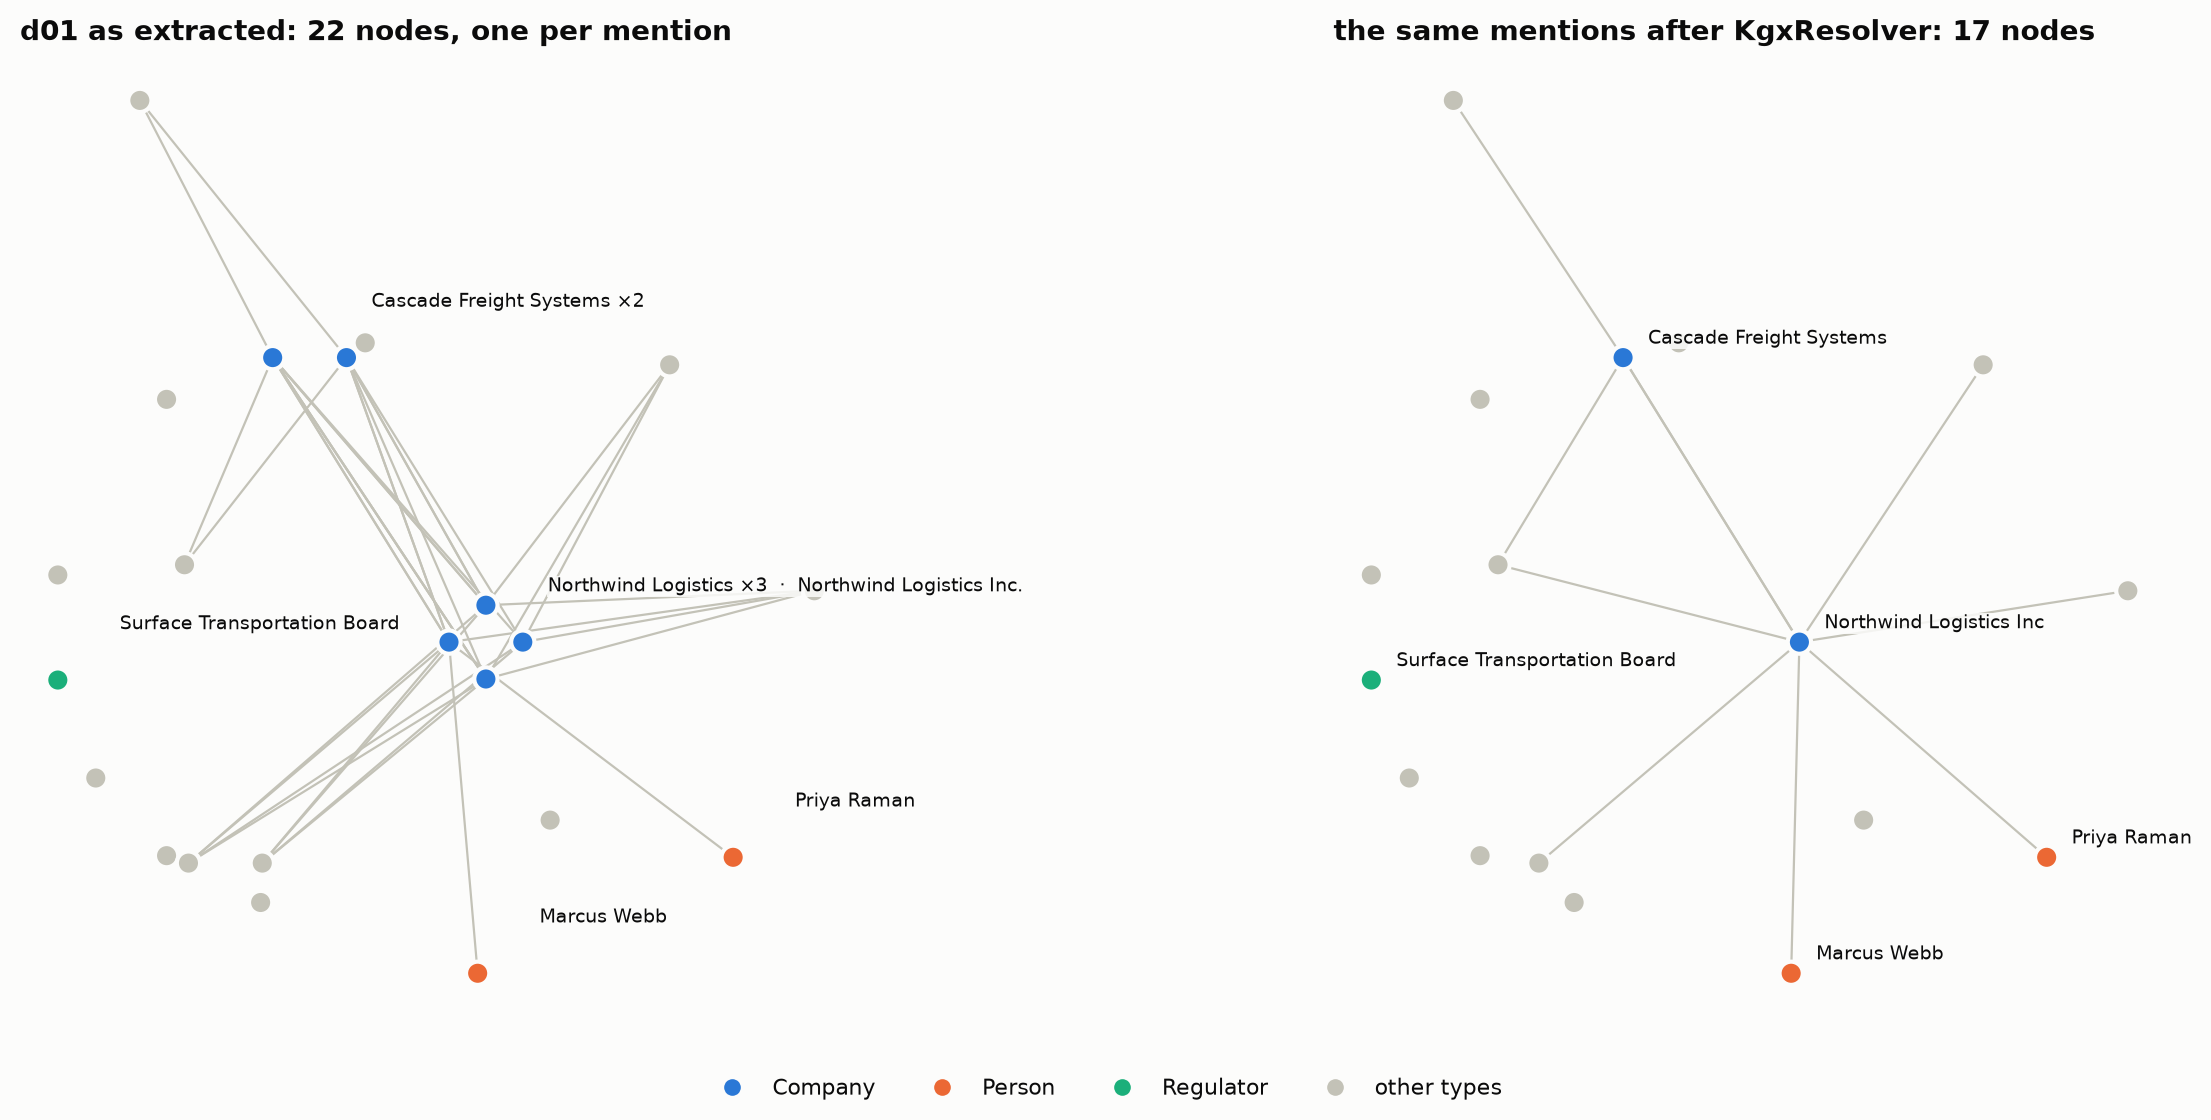

In [20]:
# Where each of d01's mentions ended up, matched by its offsets in the chunk.
rows = q("MATCH (:Document {path: 'd01'})<-[:FROM_DOCUMENT]-(:Chunk)<-[:IN_CHUNK]-(m:Mention)<-[:HAS_MENTION]-(e) "
         "RETURN m.start AS start, m.end AS end, elementId(e) AS entity, e.name AS name, "
         "       [l IN labels(e) WHERE NOT l IN ['__Entity__', '__KGBuilder__']][0] AS label")
entity_of = {(r["start"], r["end"]): r["entity"] for r in rows}
entities = {r["entity"]: (r["name"], r["label"]) for r in rows}
links = q("MATCH (e)-[:!HAS_MENTION&!FROM_CHUNK]->(o) WHERE elementId(e) IN $ids AND elementId(o) IN $ids "
          "RETURN DISTINCT elementId(e) AS a, elementId(o) AS b", ids=list(entities))
after_edges = [(r["a"], r["b"]) for r in links if r["a"] != r["b"]]

before = component_graphs["d01"]
mentions = {n.id: n for n in before.nodes if n.label not in LEXICAL_LABELS}
home = {mid: entity_of[(n.properties["start"], n.properties["end"])] for mid, n in mentions.items()}
before_edges = [(r.start_node_id, r.end_node_id) for r in before.relationships if r.type not in LEXICAL_TYPES]

G = nx.Graph()
G.add_nodes_from(entities)
G.add_edges_from(after_edges)
pos = nx.kamada_kawai_layout(G)
members = collections.defaultdict(list)
for mid, ent in home.items():
    members[ent].append(mid)
pos_before = {}
for ent, mids in members.items():
    for i, mid in enumerate(sorted(mids)):
        angle = 2 * np.pi * i / len(mids)
        radius = 0.07 if len(mids) > 1 else 0.0
        pos_before[mid] = pos[ent] + radius * np.array([np.cos(angle), np.sin(angle)])

def panel(ax, xy, colors, edges, labels, title):
    for a, b in edges:
        ax.plot(*zip(xy[a], xy[b]), color=BASE, lw=0.8, zorder=1)
    keys = list(colors)
    ax.scatter([xy[k][0] for k in keys], [xy[k][1] for k in keys], s=70, c=[colors[k] for k in keys],
               edgecolor=SURFACE, linewidth=1.5, zorder=3)
    for (x0, y0), text in labels:
        ax.annotate(text, (x0, y0), xytext=(9, 5), textcoords="offset points", fontsize=7, color=INK, zorder=4,
                    bbox=dict(fc=SURFACE, ec="none", pad=0.3, alpha=0.85))
    ax.set_title(title); ax.axis("off"); ax.set_aspect("equal")

shown = [e for e in entities if entities[e][1] in TYPE_COLOR]
before_labels = []
for ent in shown:
    forms = collections.Counter(mentions[mid].properties["name"] for mid in members[ent])
    before_labels.append((pos[ent] + 0.07, "  ·  ".join(f"{f} ×{k}" if k > 1 else f for f, k in forms.most_common())))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
panel(axes[0], pos_before, {m: type_color(mentions[m].label) for m in mentions}, before_edges, before_labels,
      f"d01 as extracted: {len(mentions)} nodes, one per mention")
panel(axes[1], pos, {e: type_color(entities[e][1]) for e in entities}, after_edges,
      [(pos[e], entities[e][0]) for e in shown],
      f"the same mentions after KgxResolver: {len(entities)} nodes")
type_legend(fig, loc="lower center", ncol=4)
fig.tight_layout(rect=(0, 0.06, 1, 1))

## 5. The package's resolvers, compared

Every resolver here is a component whose `run()` takes no input: it reads the graph from Neo4j, decides
what to merge, and merges with `apoc.refactor.mergeNodes(nodes, {properties: 'discard', mergeRels: true})`.

| resolver | what counts as the same entity | scope |
|---|---|---|
| `SinglePropertyExactMatchResolver` | same label, identical `name` — **`SimpleKGPipeline`'s default** | label |
| `FuzzyMatchResolver` | same label, rapidfuzz `WRatio(name) ≥ threshold` (default 0.8) | every pair within a label |
| `SpaCySemanticMatchResolver` | same label, cosine of spaCy's static `en_core_web_lg` vectors ≥ threshold (default 0.8) | every pair within a label |
| `KgxResolver` | kgx: normalise, block, score string + MiniLM embedding + context, cluster at 0.90 | blocked candidates within a type |

Scoring what a resolver did needs one more piece. `mergeRels: true` collapses relationships of one type to
one target, so two mentions of Northwind in one chunk leave a single `FROM_CHUNK` behind, and the lexical
graph cannot say what was merged. So before any resolver runs, `attach_mentions` gives every written entity
node a `:Mention` of its own. `HAS_MENTION` edges point at distinct nodes and survive any merge, and
`read_clusters` reads the clustering back. That is what the `MentionLayer` step in §4 is.

Each configuration below starts from the same written graph: the pruned graphs §4 produced, rewritten from
scratch, resolved once.

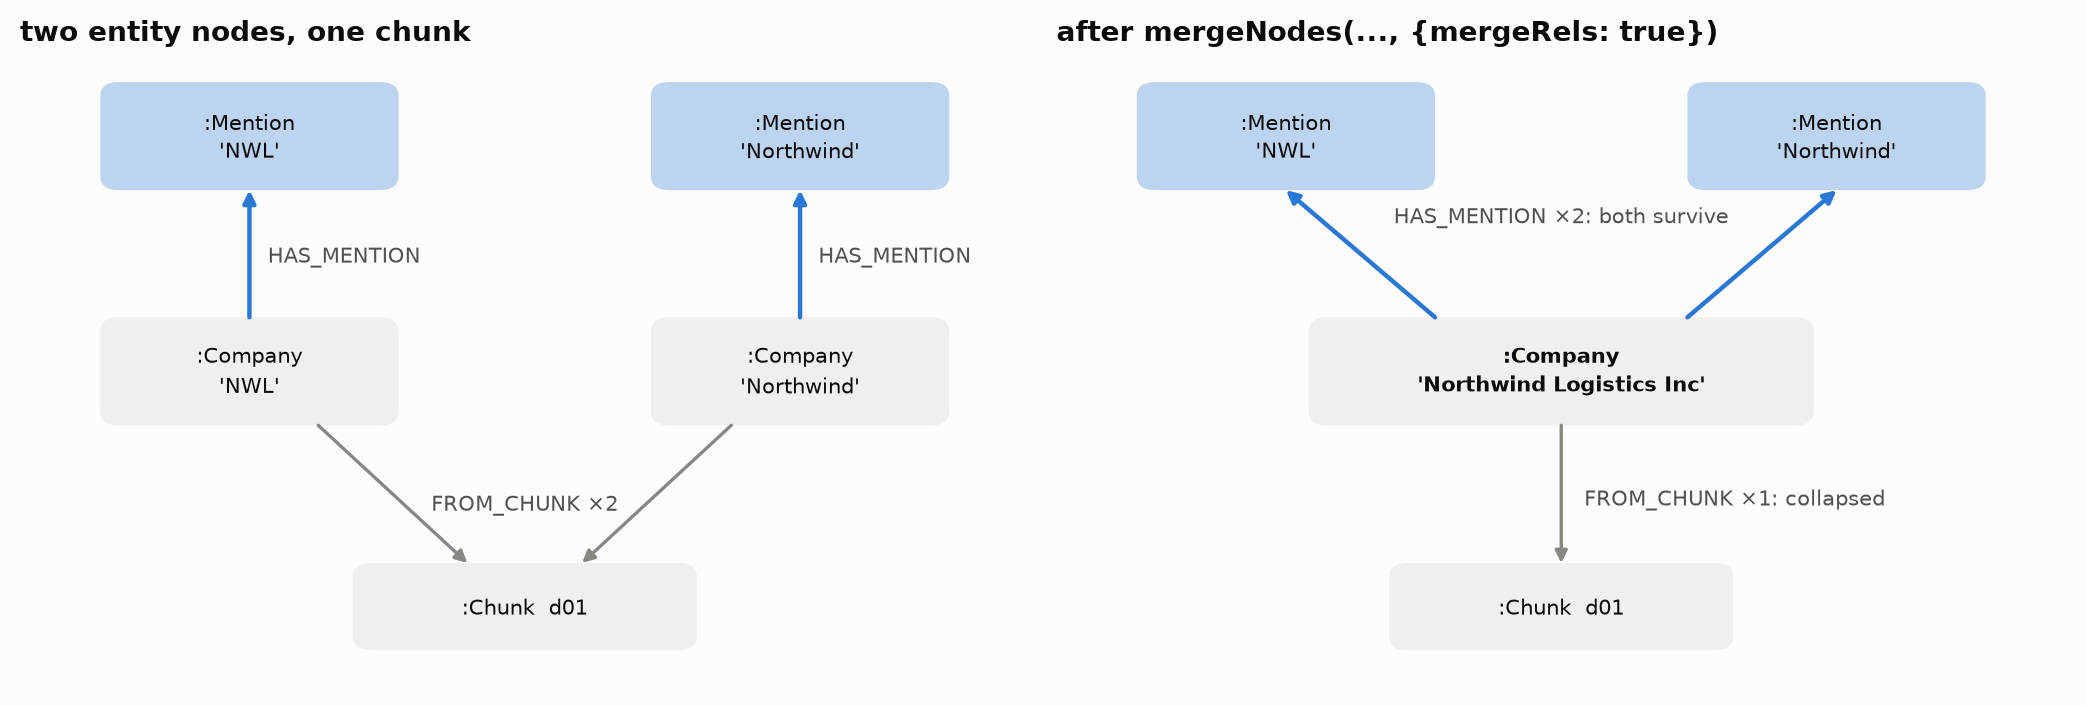

In [21]:
# Two mentions of Northwind in one chunk, before and after apoc.refactor.mergeNodes(..., {mergeRels: true}).
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
for ax, merged in zip(axes, (False, True)):
    ax.set_xlim(-0.2, 4.2); ax.set_ylim(-0.45, 3.15); ax.axis("off")
    for mx, text in ((0.8, "NWL"), (3.2, "Northwind")):
        box(ax, mx, 2.7, f":Mention\n'{text}'", w=1.3, h=0.62, fill=tint(BLUE, 0.3), size=7.5)
    box(ax, 2.0, 0.0, ":Chunk  d01", w=1.5, h=0.5, size=7.5)
    if not merged:
        for ex, text in ((0.8, "NWL"), (3.2, "Northwind")):
            box(ax, ex, 1.35, f":Company\n'{text}'", w=1.3, h=0.62, size=7.5)
            arrow(ax, (ex, 1.66), (ex, 2.39), "HAS_MENTION", color=BLUE, lw=1.6, offset=(0.08, -0.08), ha="left")
            arrow(ax, (ex + (0.3 if ex < 2 else -0.3), 1.04), (2.0 + (-0.25 if ex < 2 else 0.25), 0.25), color=MUTED)
        ax.text(2.0, 0.55, "FROM_CHUNK ×2", ha="center", fontsize=7.5, color=INK2)
        ax.set_title("two entity nodes, one chunk")
    else:
        box(ax, 2.0, 1.35, ":Company\n'Northwind Logistics Inc'", w=2.2, h=0.62, size=7.5, weight="semibold")
        for mx in (0.8, 3.2):
            arrow(ax, (2.0 + (-0.55 if mx < 2 else 0.55), 1.66), (mx, 2.39), color=BLUE, lw=1.6)
        ax.text(2.0, 2.2, "HAS_MENTION ×2: both survive", ha="center", fontsize=7.5, color=INK2)
        arrow(ax, (2.0, 1.04), (2.0, 0.25), color=MUTED)
        ax.text(2.1, 0.58, "FROM_CHUNK ×1: collapsed", ha="left", fontsize=7.5, color=INK2)
        ax.set_title("after mergeNodes(..., {mergeRels: true})")
fig.tight_layout()

In [22]:
writer = Neo4jWriter(driver, neo4j_database=config.database)

async def rewrite():
    clear_partition(driver)
    for g in PRUNED:
        await writer.run(g)
    return attach_mentions(driver)

import spacy
nlp = spacy.load("en_core_web_lg")          # load once; the resolver would load it on every construction

F = PARTITION_FILTER
RESOLVERS = {
    "none (one node per mention)": lambda: None,
    "exact match (SimpleKGPipeline)": lambda: SinglePropertyExactMatchResolver(driver, filter_query=F),
    "fuzzy 0.8 (default)": lambda: FuzzyMatchResolver(driver, filter_query=F),
    "fuzzy 0.9": lambda: FuzzyMatchResolver(driver, filter_query=F, similarity_threshold=0.9),
    "spaCy 0.8 (default)": lambda: SpaCySemanticMatchResolver(driver, filter_query=F, nlp=nlp),
    "spaCy 0.9": lambda: SpaCySemanticMatchResolver(driver, filter_query=F, nlp=nlp, similarity_threshold=0.9),
    "KgxResolver 0.90": lambda: KgxResolver(driver, filter_query=F, resolver=shared_resolver),
}

board, CLUSTERS = {}, {}
for name, make in RESOLVERS.items():
    await rewrite()
    resolver = make()
    t0 = time.perf_counter()
    if resolver is not None:
        await resolver.run()
    seconds = time.perf_counter() - t0
    CLUSTERS[name] = read_clusters(driver)
    board[name] = {**scorecard(CLUSTERS[name]), "seconds": round(seconds, 2)}
BOARD = pd.DataFrame(board).T
BOARD

,entity nodes,B3 P,B3 R,B3 F1,triples,triple F1 (strict),triple F1 (alias credit),seconds
none (one node per mention),214.0,1.0000,0.1688,0.2889,170.0,0.166,0.175,0.00
exact match (SimpleKGPipeline),123.0,1.0000,0.6379,0.7789,95.0,0.254,0.268,0.01
fuzzy 0.8 (default),90.0,0.9827,0.8143,0.8906,63.0,0.182,0.309,0.08
fuzzy 0.9,94.0,1.0000,0.8143,0.8976,63.0,0.127,0.327,0.09
spaCy 0.8 (default),103.0,1.0000,0.7077,0.8288,75.0,0.279,0.295,0.31
spaCy 0.9,117.0,1.0000,0.6965,0.8211,87.0,0.269,0.284,0.28
KgxResolver 0.90,109.0,1.0000,0.8972,0.9458,68.0,0.330,0.330,0.17


Against the 13 gold entities, the ranking is what you would guess. Exact matching (0.779) is what
`SimpleKGPipeline` gives you. Fuzzy matching buys about another 0.12 of B-cubed F1. spaCy's static vectors land
between the two. `KgxResolver` is best at 0.946 with perfect precision. `fuzzy 0.8` makes the one gold
false merge in the table: the European Commission and the Securities and Exchange Commission, which share the
word *Commission*.

Two things in that table do not fit the ranking, and both are worth a closer look. The gold labels cover 77
of the 214 mentions, all of them companies, people and regulators, so B-cubed cannot see a merge among the
other 137. And the fuzzy rows' triple scores are one draw each from a distribution: rerun this cell and they move,
sometimes above `KgxResolver`'s, sometimes below exact matching's. §5.2 shows why, and why neither number
means much.

### 5.1 The merges gold cannot see

Every node below holds mentions with two or more different normalised names, and none of those mentions is
gold-labelled. Some are right (`Telematics` / `telematics unit`). Read the rest:

In [23]:
def unlabelled_merges(rows):
    by_node = collections.defaultdict(list)
    for r in rows:
        by_node[r["entity"]].append(r)
    out = []
    for members in by_node.values():
        if any(r["text"].strip() in VARIANT for r in members):
            continue
        forms = sorted({r["text"] for r in members})
        if len({kgx.normalize(t, model_name(members[0]["label"])).key for t in forms}) > 1:
            out.append((members[0]["label"], " | ".join(forms)))
    return sorted(out)

side = {name: unlabelled_merges(rows) for name, rows in CLUSTERS.items()}
BOARD["unlabelled merges"] = pd.Series({k: len(v) for k, v in side.items()})
for name in ("fuzzy 0.8 (default)", "fuzzy 0.9", "spaCy 0.8 (default)", "KgxResolver 0.90"):
    merges = side[name]
    print(f"{name} — {len(merges)} nodes")
    for label, forms in merges:
        print(f"    {label:16} {forms}")
    print()

fuzzy 0.8 (default) — 13 nodes
    BusinessEvent    Cascade Freight transaction | transaction
    BusinessSegment  Telematics | Telematics unit | telematics unit
    FinancialMetric  $28.50 per share | Adjusted earnings per share | adjusted earnings per share | non-GAAP earnings per share
    FinancialMetric  Adjusted operating margin | adjusted operating margin | gross margin | margin | margins | non-GAAP gross margin | operating margin
    FinancialMetric  dividend | quarterly dividend
    FinancialMetric  revenue | second quarter revenue
    Geography        Arizona | PHOENIX | Phoenix | Phoenix, Arizona
    Geography        Dresden | Dresden, Germany | Germany
    Geography        Europe | European Union
    Product          power management chips | power management controllers
    RiskFactor       price | spot rack prices
    Sector           Freight | freight | freight brokerage
    Sector           automotive | automotive analog

fuzzy 0.9 — 11 nodes
    BusinessEvent    Cascade

Side by side, the scoreboard and what it cannot see:

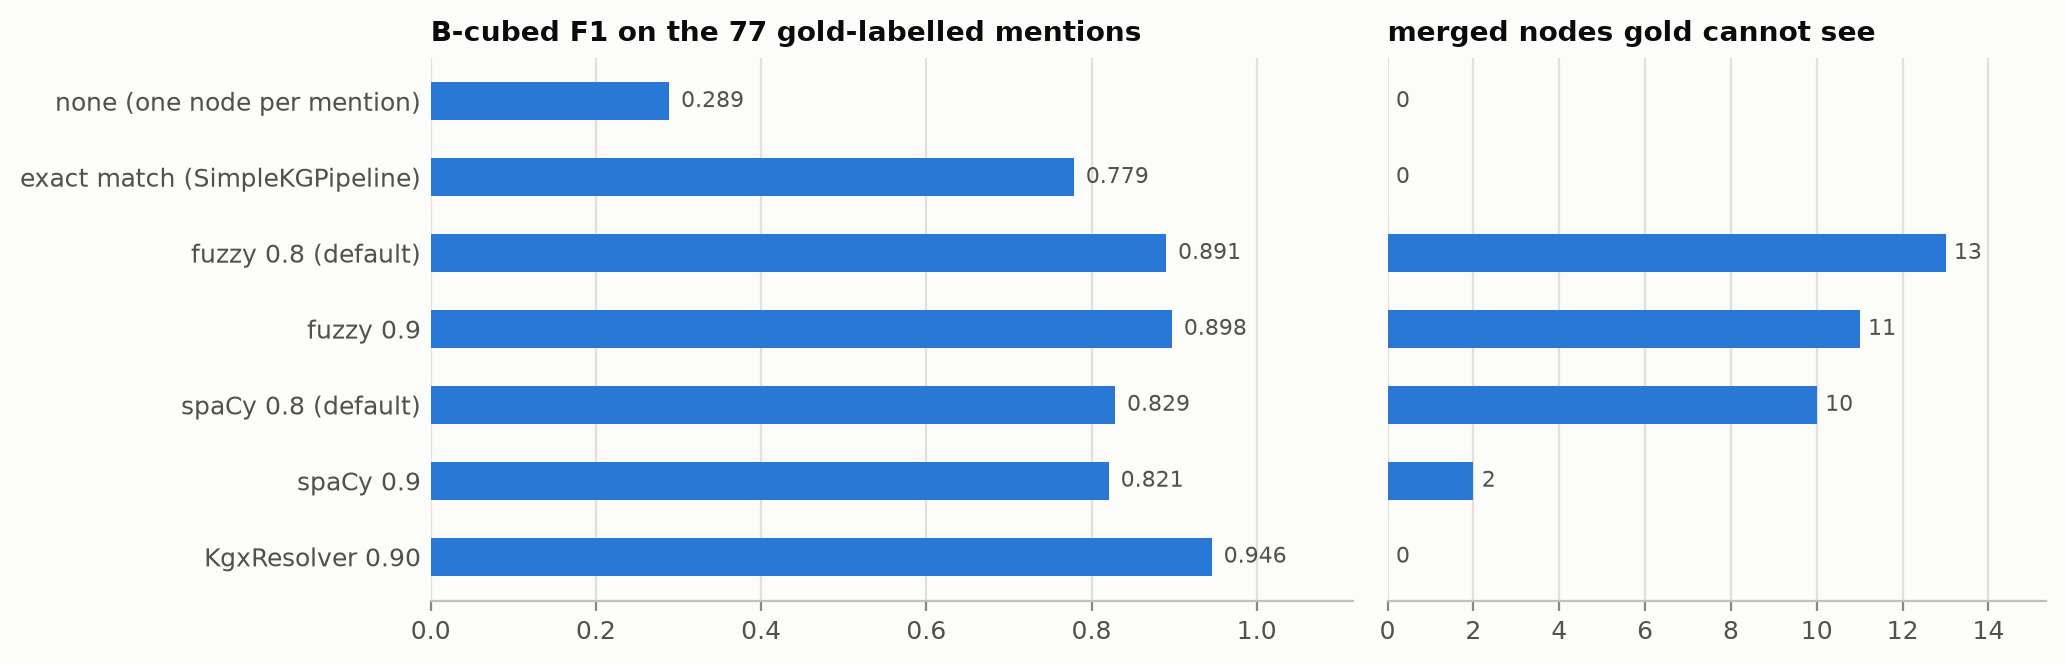

In [24]:
names = list(BOARD.index)[::-1]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4), sharey=True, gridspec_kw={"width_ratios": (1.4, 1)})
for ax, col, fmt, title in ((axes[0], "B3 F1", "{:.3f}", "B-cubed F1 on the 77 gold-labelled mentions"),
                            (axes[1], "unlabelled merges", "{:.0f}", "merged nodes gold cannot see")):
    values = BOARD.loc[names, col].astype(float)
    ax.barh(names, values, height=0.5, color=BLUE)
    for i, v in enumerate(values):
        ax.text(v + values.max() * 0.015, i, fmt.format(v), va="center", fontsize=8, color=INK2)
    ax.set_title(title); ax.set_xlim(0, values.max() * 1.18)
    ax.tick_params(axis="y", length=0); ax.spines["left"].set_visible(False)
    ax.grid(axis="x"); ax.set_axisbelow(True)
fig.tight_layout()

`Phoenix` merged with `Arizona`, `Dresden` with `Germany`, and `Europe` with the `European Union`. `revenue`
with `second quarter revenue`. Every kind of margin — gross, operating, adjusted, non-GAAP — collapsed into one
node, and `$28.50 per share` into adjusted earnings per share. spaCy adds `Seattle` with `Chicago` and `Asia
Pacific` with `Pacific Northwest`: static word vectors put two cities, or two regions, close together, which
is what they are for and not what identity is.

The fuzzy failures have one mechanism. `WRatio` takes the best of several scorers, including a *partial*
ratio, which scores a string contained in another at 100 and then scales it to 90. `Arizona` inside `Phoenix,
Arizona` passes any threshold up to 0.9, and each merge makes the next one easier. Notebook 01 found the same
shape by hand — *"a prefix match is not an identity"* — and notebook 09's *"'Precision 1.000' was a property
of the corpus, not the resolver"* is this table's warning exactly: `fuzzy 0.9` scores precision 1.000 on gold
while making eleven merges gold cannot see. A few are defensible (`Telematics` / `telematics unit`,
`dividend` / `quarterly dividend`); most are not.

`KgxResolver`'s column is empty. String similarity is under half of its score: a pair has to clear 0.90 on
string, embedding and context evidence together, unless a deterministic rule fires — an identical normalised
form, an alias the text declares, an acronym expansion, or an organisation-name prefix with agreeing context.
Containment alone never carries a pair over the line, so a city does not merge with its state.

### 5.2 The name that survives

`mergeNodes` with `properties: 'discard'` keeps the first node's properties, and the built-in similarity
resolvers pass the nodes to merge as `list(set_of_element_ids)`. So which node comes first — and which
surface form becomes the entity's `name` — is Python set order over element ids. Those ids are new on every
write, so the order is too. The same resolver on the same graph, eight times:

In [25]:
def name_of(rows, text, label):
    # the name on the node that the mention `text` (typed `label`) ended up in
    return next(r["name"] for r in rows if r["text"] == text and r["label"] == label)

def partition(rows):
    # the clustering as sets of stable span keys, comparable across rewrites
    by_node = collections.defaultdict(set)
    for r in rows:
        by_node[r["entity"]].add(r["key"])
    return {frozenset(s) for s in by_node.values()}

def acquires_edge():
    r = q("MATCH (a)-[:HAS_MENTION]->(:Mention {text: 'Northwind Logistics Inc.', label: 'Company'}), "
          "(b)-[:HAS_MENTION]->(:Mention {text: 'Cascade Freight Systems'}), (a)-[r:ACQUIRES]->(b) "
          "RETURN r.confidence AS c, r.support AS s LIMIT 1")
    return f"confidence {r[0]['c']:.2f}, support {r[0]['s']}" if r else "—"

runs, first = [], None
for i in range(8):
    await rewrite()
    await RESOLVERS["fuzzy 0.9"]().run()
    rows = read_clusters(driver)
    card = scorecard(rows)
    first = first or partition(rows)
    runs.append({"run": i + 1, "same clustering as run 1": partition(rows) == first,
                 "Northwind's name": name_of(rows, "Northwind Logistics Inc.", "Company"),
                 "Halcyon's name": name_of(rows, "Halcyon Semiconductor Corporation", "Company"),
                 "the Dresden node's name": name_of(rows, "Dresden", "Geography"),
                 "Northwind ACQUIRES Cascade": acquires_edge(),
                 "B3 F1": card["B3 F1"], "triple F1 (strict)": card["triple F1 (strict)"],
                 "triple F1 (alias credit)": card["triple F1 (alias credit)"]})
pd.DataFrame(runs).set_index("run")

,same clustering as run 1,Northwind's name,Halcyon's name,the Dresden node's name,Northwind ACQUIRES Cascade,B3 F1,triple F1 (strict),triple F1 (alias credit)
run,,,,,,,,
1,True,Northwind Logistics Inc.,Halcyon Semiconductor Corporation,Germany,"confidence 0.56, support None",0.8976,0.345,0.345
2,True,Northwind Logistics Inc.,Halcyon,Dresden,"confidence 0.93, support None",0.8976,0.182,0.345
3,True,Northwind Logistics,Halcyon Semiconductor,Dresden,"confidence 0.94, support None",0.8976,0.309,0.364
4,True,Northwind Logistics,Halcyon,"Dresden, Germany","confidence 0.93, support None",0.8976,0.200,0.327
5,True,Northwind Logistics,Halcyon,Germany,"confidence 0.94, support None",0.8976,0.182,0.327
6,True,Northwind Logistics,Halcyon Semiconductor,Germany,"confidence 0.94, support None",0.8976,0.327,0.327
7,True,Northwind Logistics,Halcyon Semiconductor,"Dresden, Germany","confidence 0.52, support None",0.8976,0.327,0.327
8,True,Northwind Logistics,Halcyon Semiconductor,"Dresden, Germany","confidence 0.53, support None",0.8976,0.345,0.345


As a picture, each dot one of those runs:

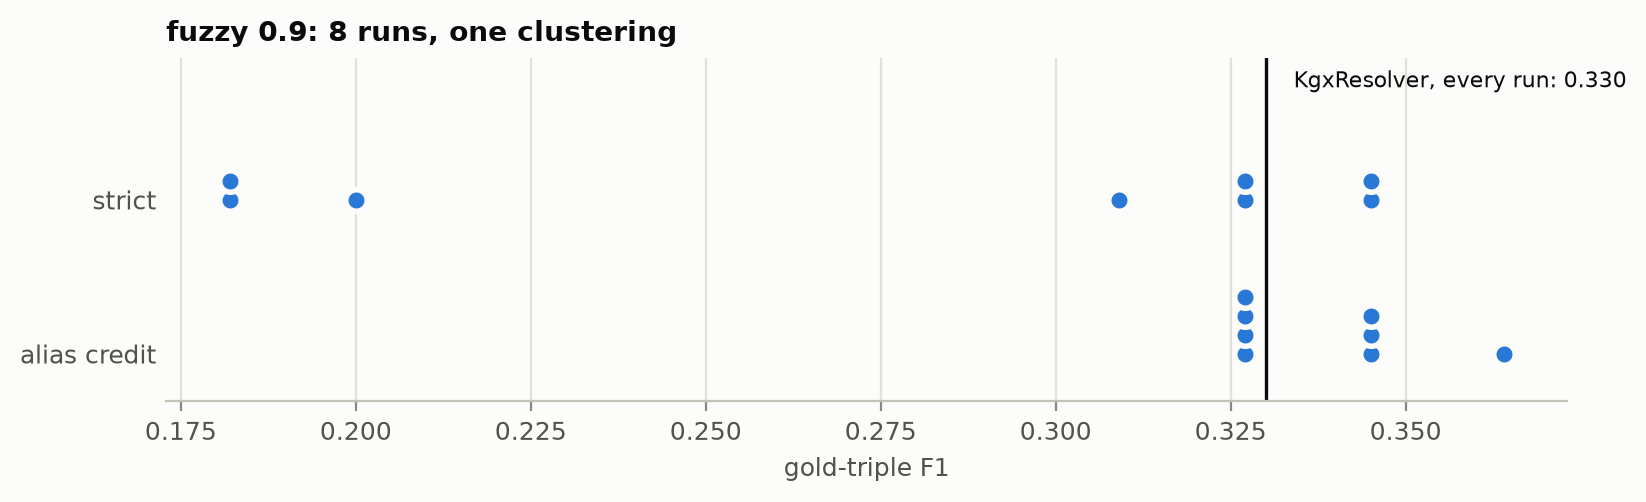

In [26]:
fig, ax = plt.subplots(figsize=(8.5, 2.6))
for row, col in enumerate(("triple F1 (alias credit)", "triple F1 (strict)")):
    stacked = collections.Counter()
    for v in pd.DataFrame(runs)[col].round(3):          # identical scores stack upwards, one dot per run
        ax.scatter([v], [1.3 * row + 0.16 * stacked[v]], s=60, color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=3)
        stacked[v] += 1
kgx_f1 = BOARD.loc["KgxResolver 0.90", "triple F1 (strict)"]
ax.axvline(kgx_f1, color=INK, lw=1.2, zorder=2)
ax.text(kgx_f1 + 0.004, 2.25, f"KgxResolver, every run: {kgx_f1:.3f}", fontsize=8, color=INK)
ax.set_yticks([0, 1.3], ["alias credit", "strict"]); ax.set_ylim(-0.4, 2.5)
ax.tick_params(axis="y", length=0); ax.spines["left"].set_visible(False)
ax.set_xlabel("gold-triple F1"); ax.grid(axis="x"); ax.set_axisbelow(True)
ax.set_title(f"fuzzy 0.9: {len(runs)} runs, one clustering")
fig.tight_layout()

The clustering is identical on every run — the same spans in the same nodes, and the same B-cubed. The
names are not: each run names Northwind, Halcyon and the rest with whichever of their forms APOC saw first.
Both triple scores move with the names, because a triple is matched by the names on its endpoints:

- **The strict score** gets no help from the evaluator's alias table, so it collapses whenever a company is
  named by a short form no gold triple uses — `Northwind`, `Halcyon`.
- **The alias-credit score** survives those, because the *evaluator* resolves the company names on the
  pipeline's behalf (notebook 07's §7 finding, from the other side). But nothing resolves places. Three gold
  triples name places the fuzzy resolver over-merged — Halcyon in `Dresden` and in `Phoenix`, Northwind in
  the `European Union` — and each matches only on the runs where its merged node drew the name gold uses.
  The Dresden column is one of those three draws.

That also explains how the fuzzy rows can match or beat `KgxResolver` on triples. Their over-merges collapse
triples — 63 against 68 — and on a good name draw they match as many gold triples (19), occasionally one
more. The same matches out of fewer triples is higher precision. Collapsing a city into its country is not
better resolution, and a triple score that rewards it is scoring the wrong thing.

The edge column is the same effect on relationships. Merging collapses the parallel copies of `Northwind
ACQUIRES Cascade` into one and keeps whichever copy APOC saw first, so its confidence changes from run to
run and its support — how many times it was extracted — is simply absent.

This is what "resolution" means without canonicalisation. The duplicates are gone, but the one node left is
named at random, and every other name is deleted. A query for `MATCH (c:Company {name: 'Northwind Logistics
Inc.'})` works on some runs and not others.

`KgxResolver` chooses the canonical name (the longest form, with the legal suffix) and writes every surface
form to `aliases`. It merges into the node that already holds most of the cluster, so the surviving element
id is stable as well.

### 5.3 Resolving after every document

`SimpleKGPipeline` runs its resolver at the end of every `run_async` — once per document, over the whole
database. A resolver that compares *nodes* then sees, from the second document on, nodes that earlier merges
have reduced to one arbitrary name. The table replays §4's documents in order and resolves after each, then
compares with resolving once at the end:

In [27]:
async def resolve_per_document(make):
    clear_partition(driver)
    resolver = make()
    for g in PRUNED:
        await writer.run(g)
        attach_mentions(driver)
        await resolver.run()
    return read_clusters(driver)

import re
from kgx.extract import Mention

class NodeLevelKgxResolver(KgxResolver):
    # The same resolver pointed at entity nodes instead of their mentions: one "mention" per node, named
    # by the node's current name -- which is what the package's resolvers compare.
    def read_mentions(self):
        rows = q(f"MATCH (entity:__Entity__) {self.filter_query} "
                 "OPTIONAL MATCH (entity)-[:FROM_CHUNK]->(c:Chunk)-[:FROM_DOCUMENT]->(d:Document) "
                 "WITH entity, head(collect(c)) AS c, head(collect(d)) AS d "
                 "RETURN elementId(entity) AS id, entity.name AS text, entity.start AS start, entity.end AS end, "
                 "  [l IN labels(entity) WHERE NOT l IN ['__Entity__', '__KGBuilder__']][0] AS label, "
                 "  c.text AS chunk, d.path AS doc")
        mentions = [Mention(mention_id=r["id"], doc_id=r["doc"] or "", type=model_name(r["label"]),
                            text=r["text"], start=r["start"] or 0, end=r["end"] or 0,
                            context=re.sub(r"\s+", " ", (r["chunk"] or "")[max(0, (r["start"] or 0) - 90):
                                                                          (r["end"] or 0) + 90]))
                    for r in rows]
        return mentions, {m.mention_id: m.mention_id for m in mentions}, sorted({r["chunk"] for r in rows if r["chunk"]})

RESOLVERS["KgxResolver over nodes"] = lambda: NodeLevelKgxResolver(driver, filter_query=F,
                                                                  resolver=kgx.EntityResolver(threshold=0.90))

async def resolve_once(make):
    await rewrite()
    await make().run()
    return read_clusters(driver)

def northwind_aliases():
    rows = q("MATCH (e:Company:__KGBuilder__)-[:HAS_MENTION]->(:Mention {text: 'NWL'}) RETURN e.aliases AS a")
    return len(rows[0]["a"] or []) if rows else None

incremental = {}
for name in ("exact match (SimpleKGPipeline)", "fuzzy 0.9", "KgxResolver over nodes", "KgxResolver 0.90"):
    once = scorecard(await resolve_once(RESOLVERS[name]))
    per_doc = scorecard(await resolve_per_document(RESOLVERS[name]))
    incremental[name] = {"B3 F1 once": once["B3 F1"], "B3 F1 per document": per_doc["B3 F1"],
                         "nodes once": once["entity nodes"], "nodes per document": per_doc["entity nodes"],
                         "triple F1 per document (strict)": per_doc["triple F1 (strict)"],
                         "Northwind aliases kept": northwind_aliases()}
pd.DataFrame(incremental).T

,B3 F1 once,B3 F1 per document,nodes once,nodes per document,triple F1 per document (strict),Northwind aliases kept
exact match (SimpleKGPipeline),0.7789,0.7789,123.0,123.0,0.254,0.0
fuzzy 0.9,0.8976,0.8976,94.0,96.0,0.180,0.0
KgxResolver over nodes,0.9458,0.9269,109.0,110.0,0.310,2.0
KgxResolver 0.90,0.9458,0.9458,109.0,109.0,0.330,5.0


Exact matching cannot tell the difference: a merged node keeps a name identical to the ones it absorbed.
The fuzzy resolver barely notices on this corpus — a few nodes more, the same B-cubed — because `WRatio`
matches a surviving short form about as readily as the long one. It never had aliases to lose.

The resolver that loses is the good one. `KgxResolver over nodes` is the same resolver reading entity nodes,
as the package's resolvers do, instead of mentions. Resolved once, on a fresh graph where every node *is*
one mention, the two are identical. Resolved after every document, the node-level version loses B-cubed:
from the second document on, each merged node offers one name and one chunk of context, and the evidence that
merged it — the other surface forms, the other contexts — is gone. It cannot keep the aliases either, since
it never sees them again.

`KgxResolver` gives the same answer both ways because it never compares nodes. Every run clusters *all the
mentions* in scope — every surface form, each with the text of its own chunk — and merges whichever nodes
each cluster's mentions sit on. The mention layer is not only there to score resolution. It is what makes
resolution incremental.

### 5.4 A latent bug: merge sets that overlap

The similarity resolvers collect every pair above threshold, then consolidate the pairs into merge sets with
`_consolidate_sets`. That is a single pass that adds each pair to the *first* set it touches — which is not
transitive:

In [28]:
pairs = [{"A1", "A2"}, {"B1", "B2"}, {"A2", "B1"}]
print("built-in :", FuzzyMatchResolver._consolidate_sets([set(p) for p in pairs]))
print("union-find:", consolidate_transitively([set(p) for p in pairs]))

built-in : [{'A2', 'B1', 'A1'}, {'B1', 'B2'}]
union-find: [{'A2', 'B1', 'B2', 'A1'}]


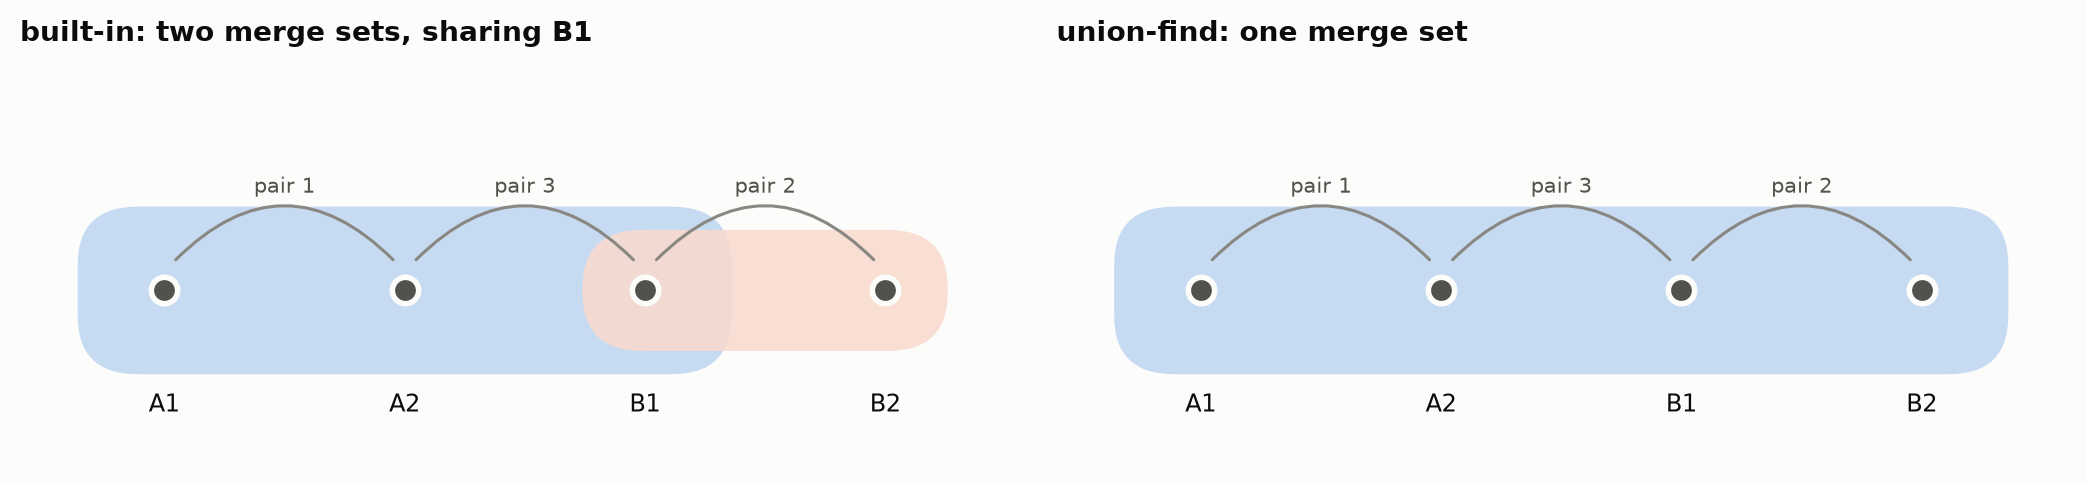

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 2.5))
xs = {"A1": 0, "A2": 1, "B1": 2, "B2": 3}
panels = ((axes[0], [({"A1", "A2", "B1"}, BLUE), ({"B1", "B2"}, ORANGE)], "built-in: two merge sets, sharing B1"),
          (axes[1], [({"A1", "A2", "B1", "B2"}, BLUE)], "union-find: one merge set"))
for ax, sets, title in panels:
    ax.set_xlim(-0.6, 3.6); ax.set_ylim(-0.75, 1.0); ax.axis("off")
    for k, (members, color) in enumerate(sets):
        lo, hi = min(xs[m] for m in members), max(xs[m] for m in members)
        pad = 0.36 - 0.1 * k
        ax.add_patch(FancyBboxPatch((lo - pad, -pad), hi - lo + 2 * pad, 2 * pad, fc=tint(color, 0.28 - 0.06 * k),
                                    ec="none", alpha=0.9, boxstyle="round,pad=0,rounding_size=0.25"))
    for n, i in xs.items():
        ax.scatter([i], [0], s=90, color=INK2, edgecolor=SURFACE, linewidth=2, zorder=3)
        ax.text(i, -0.52, n, ha="center", fontsize=8.5)
    for step, (a, b) in enumerate(pairs, start=1):
        a, b = sorted((a, b))
        ax.add_patch(FancyArrowPatch((xs[a], 0.08), (xs[b], 0.08), arrowstyle="-", lw=1.1, color=MUTED,
                                     connectionstyle="arc3,rad=-0.55", shrinkA=6, shrinkB=6))
        ax.text((xs[a] + xs[b]) / 2, 0.42, f"pair {step}", ha="center", fontsize=7.5, color=INK2)
    ax.set_title(title)
fig.tight_layout()

`{A2, B1}` bridges the two sets already built. It joins the first, so `B1` ends up in both. Each set becomes
one `mergeNodes` call. Whether the second call still finds `B1` depends on which node survived the first,
which is set order again. So the same four nodes end as one entity on some runs and two on others. Here is
the real `run()`, driven by a scripted similarity so the bridging pair is guaranteed, twelve times over each
node order:

In [30]:
class Scripted(BasePropertySimilarityResolver):
    SAME = {frozenset(p) for p in pairs}
    def compute_similarity(self, a, b):
        return 1.0 if frozenset((a, b)) in self.SAME else 0.0

class ScriptedUnionFind(Scripted):
    _consolidate_sets = staticmethod(consolidate_transitively)

async def nodes_left(cls, order):
    q("MATCH (n {bug_probe: true}) DETACH DELETE n")
    for name in order:
        q("CREATE (:__Entity__:Company {name: $name, bug_probe: true})", name=name)
    await cls(driver, filter_query="WHERE entity.bug_probe = true", similarity_threshold=0.5).run()
    left = len(q("MATCH (n {bug_probe: true}) RETURN n"))
    q("MATCH (n {bug_probe: true}) DETACH DELETE n")
    return left

rows = []
for order in (["A1", "A2", "B1", "B2"], ["A1", "B1", "B2", "A2"], ["B1", "A1", "B2", "A2"]):
    builtin = collections.Counter([await nodes_left(Scripted, order) for _ in range(12)])
    fixed = collections.Counter([await nodes_left(ScriptedUnionFind, order) for _ in range(12)])
    rows.append({"node order": " ".join(order),
                 "built-in: nodes left (runs)": dict(sorted(builtin.items())),
                 "union-find: nodes left (runs)": dict(sorted(fixed.items()))})
pd.DataFrame(rows).set_index("node order")

,built-in: nodes left (runs),union-find: nodes left (runs)
node order,,
A1 A2 B1 B2,{1: 12},{1: 12}
A1 B1 B2 A2,"{1: 4, 2: 8}",{1: 12}
B1 A1 B2 A2,{1: 12},{1: 12}


With nodes in the order that makes the bridging pair arrive last, the built-in leaves two nodes on some runs;
the union-find always leaves one. `TransitiveFuzzyMatchResolver` is `FuzzyMatchResolver` with that one
static method replaced. **On this corpus it changes nothing** — the check below finds identical clusterings
at both thresholds. The bug needs a pair that bridges two sets built earlier in the pass, and this corpus's
pair order never produced one. It is a latent bug, and it would show up as a nondeterministic under-merge
on a larger corpus.

In [31]:
for th in (0.8, 0.9):
    partitions = []
    for cls in (FuzzyMatchResolver, TransitiveFuzzyMatchResolver):
        await rewrite()
        await cls(driver, filter_query=F, similarity_threshold=th).run()
        partitions.append(partition(read_clusters(driver)))
    print(f"threshold {th}: built-in and union-find clusterings identical: {partitions[0] == partitions[1]} "
          f"({len(partitions[0])} nodes)")

threshold 0.8: built-in and union-find clusterings identical: True (90 nodes)


threshold 0.9: built-in and union-find clusterings identical: True (94 nodes)


### 5.5 Scope: labels are types

The resolvers group candidates by **every label on a node** except `__Entity__` and `__KGBuilder__`. Put a
partition label on your entities — as notebook 15 did with `__Decide__` — and the resolvers treat it as one
more entity type. Each node is then resolved once per label, and every node in the partition lands in the
same comparison group, whatever its type. The same probe, with one extra label:

In [32]:
q("MATCH (n {bug_probe: true}) DETACH DELETE n")
for name in ["A1", "A2", "B1", "B2"]:
    q("CREATE (:__Entity__:Company:Partition {name: $name, bug_probe: true})", name=name)
stats = await ScriptedUnionFind(driver, filter_query="WHERE entity.bug_probe = true",
                                similarity_threshold=0.5).run()
q("MATCH (n {bug_probe: true}) DETACH DELETE n")
print(f"4 nodes, labels Company + Partition -> number_of_nodes_to_resolve = {stats.number_of_nodes_to_resolve}")

4 nodes, labels Company + Partition -> number_of_nodes_to_resolve = 8


That is why this notebook scopes by `__KGBuilder__`, one of the two labels the resolvers skip, and why every
resolver here gets a `filter_query`. Without it, the first `FuzzyMatchResolver.run()` would also have merged
the other notebooks' 212 entities in this database into each other.

The same grouping explains the type wall from the other side. `HLCN` typed as a security is never compared
with Halcyon the company by any resolver in this table, `KgxResolver` included.

Putting the `KgxResolver` graph back for §6:

In [33]:
await rewrite()
stats = await KgxResolver(driver, filter_query=F, resolver=shared_resolver).run()
print(stats)
pd.Series(scorecard(read_clusters(driver)), name="restored")

number_of_nodes_to_resolve=214 number_of_created_nodes=109


entity nodes                109.0000
B3 P                          1.0000
B3 R                          0.8972
B3 F1                         0.9458
triples                      68.0000
triple F1 (strict)            0.3300
triple F1 (alias credit)      0.3300
Name: restored, dtype: float64

## 6. What the graph is for

Retrieval, with the package's own retriever and still no LLM: `VectorCypherRetriever` finds chunks by
MiniLM embedding (the pipeline wrote them) and walks from each chunk to the resolved entities extracted from
it, and their relationships. This is the retrieval half of GraphRAG, and it does not need a model that
writes text. Only the generation step would. Notebook 02 covers the generation step; here the point is what
arrives in the context.

In [34]:
from neo4j_graphrag.indexes import create_vector_index
from neo4j_graphrag.retrievers import VectorCypherRetriever
from neo4j_graphrag.types import RetrieverResultItem

INDEX = "kgbuilder_chunk_vec"
create_vector_index(driver, INDEX, label="Chunk", embedding_property="embedding",
                    dimensions=len(embedder.embed_query("probe")), similarity_fn="cosine")

# Facts between two entities that were both extracted from the retrieved chunk, best supported first.
# Relationships are merged across documents, so this is the graph around the chunk, not its provenance.
CHUNK_TO_GRAPH = '''
MATCH (node)-[:FROM_DOCUMENT]->(d:Document)
MATCH (node)<-[:FROM_CHUNK]-(e:__Entity__)
OPTIONAL MATCH (e)-[r]->(o:__Entity__)-[:FROM_CHUNK]->(node)
WITH node, d, e, r, o ORDER BY r.support DESC, r.confidence DESC
WITH node, d, collect(DISTINCT e.name) AS entities,
     collect(DISTINCT e.name + ' -[' + type(r) + ']-> ' + o.name) AS facts
RETURN d.path AS doc, node.text AS text, entities, facts
'''

def show(record):
    return RetrieverResultItem(content=(
        f"[{record['doc']}] {record['text'][:110]}...\n"
        f"    entities: {', '.join(record['entities'][:8])}\n"
        f"    facts:    " + "\n              ".join(record["facts"][:7])))

retriever = VectorCypherRetriever(driver, index_name=INDEX, embedder=embedder,
                                  retrieval_query=CHUNK_TO_GRAPH, result_formatter=show,
                                  neo4j_database=config.database)
for item in retriever.search(query_text="Who is buying Cascade Freight, and who has to approve it?",
                             top_k=2).items:
    print(item.content, "\n")

[d01] SEATTLE — Northwind Logistics Inc. (NASDAQ: NWL) today announced that it has entered into a definitive agreeme...
    entities: Seattle, Surface Transportation Board, acquisition, agreement, cash, less-than-truckload market, Pacific Northwest, adjusted earnings per share
    facts:    Northwind Logistics Inc -[PARTICIPANT_IN]-> transaction
              Northwind Logistics Inc -[REPORTS_METRIC]-> revenue
              Northwind Logistics Inc -[PARTNERS_WITH]-> Cascade Freight Systems
              Northwind Logistics Inc -[ACQUIRES]-> Cascade Freight Systems
              Priya Raman -[OFFICER_OF]-> Northwind Logistics Inc
              Marcus Webb -[OFFICER_OF]-> Northwind Logistics Inc
              Northwind Logistics Inc -[PARTICIPANT_IN]-> acquisition 

[d07] Item 8.01. On May 4, 2026, Northwind Logistics Inc. (the "Company") received a subpoena from the Securities an...
    entities: revenue, Securities and Exchange Commission, Western District of Washington, linehaul, Unit

The graph those facts come from, around one entity. Line width is `support`: how many extracted relations
each resolved edge stands for.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


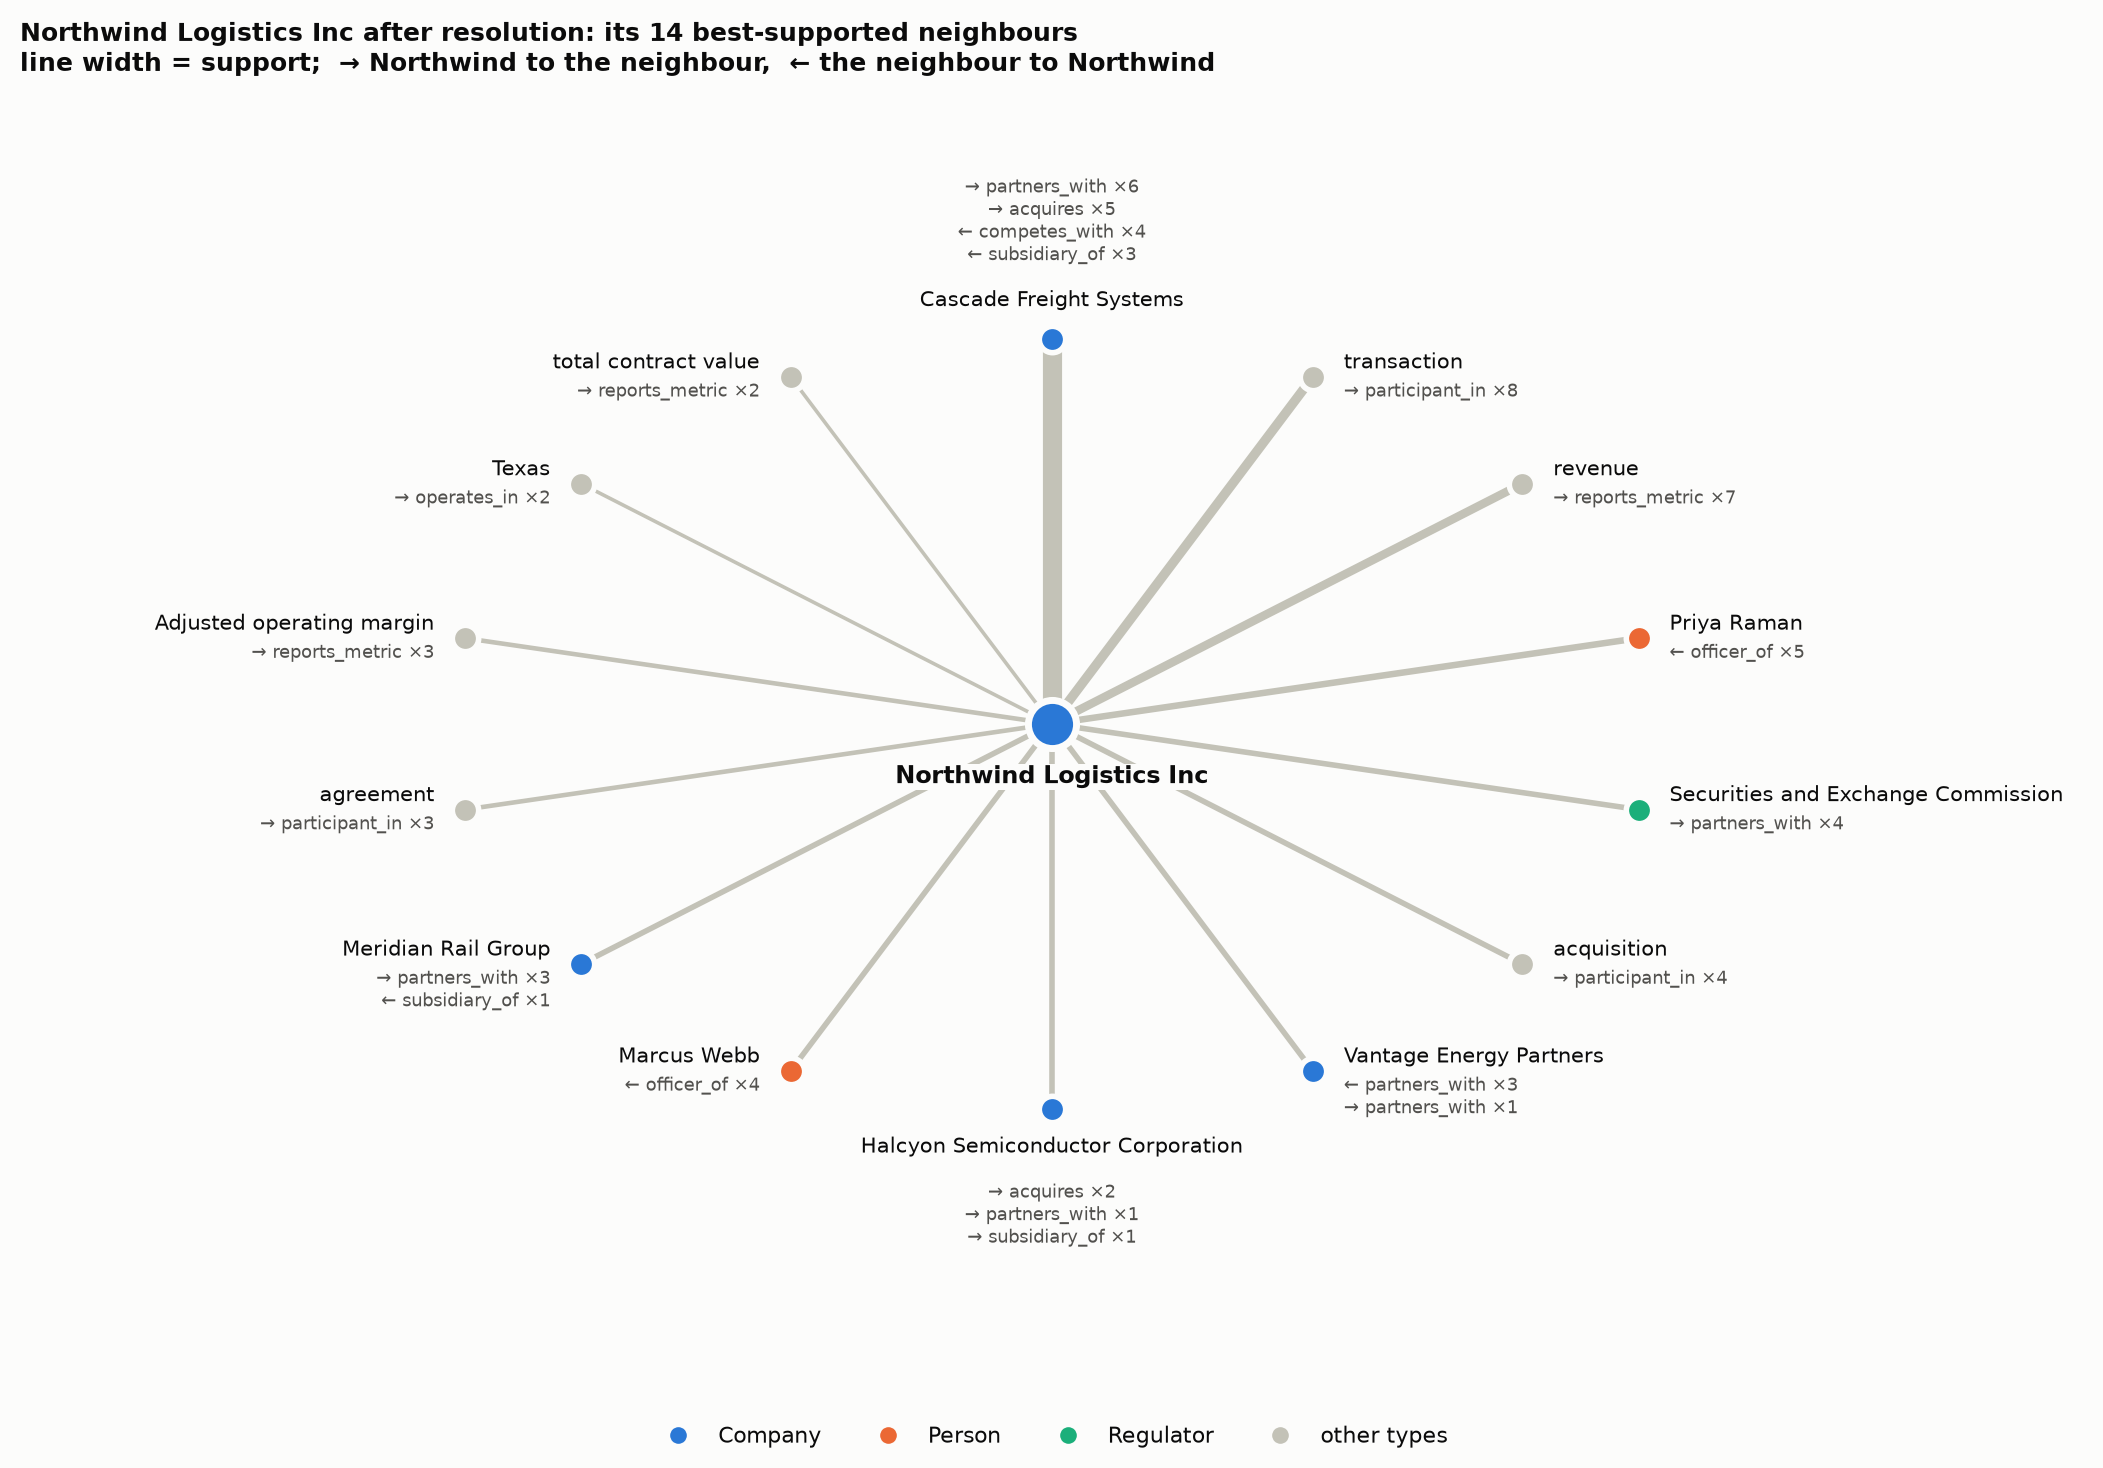

In [35]:
nbr = pd.DataFrame(q(
    "MATCH (n:Company:__KGBuilder__ {name: 'Northwind Logistics Inc'})-[r]-(o:__Entity__) "
    "RETURN o.name AS other, [l IN labels(o) WHERE NOT l IN ['__Entity__', '__KGBuilder__']][0] AS label, "
    "       type(r) AS type, startNode(r) = n AS outgoing, r.support AS support"))
totals = nbr.groupby("other")["support"].sum().sort_values(ascending=False).head(14)
angles = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, len(totals), endpoint=False)
pos = {o: (1.75 * np.cos(t), 1.12 * np.sin(t)) for o, t in zip(totals.index, angles)}

fig, ax = plt.subplots(figsize=(11, 7.2))
for other, (px, py) in pos.items():
    ax.plot([0, px], [0, py], color=BASE, lw=0.6 + 0.35 * totals[other], solid_capstyle="round", zorder=1)
for (other, (px, py)), t in zip(pos.items(), angles):
    mine = nbr[nbr["other"] == other].sort_values("support", ascending=False)
    ax.scatter([px], [py], s=90, color=type_color(mine["label"].iloc[0]), edgecolor=SURFACE, linewidth=2, zorder=3)
    rels = "\n".join(f"{'→' if r.outgoing else '←'} {r.type.lower()} ×{r.support}" for r in mine.itertuples())
    style = dict(zorder=4, bbox=dict(fc=SURFACE, ec="none", pad=0.4))
    if abs(np.cos(t)) > 0.3:                     # at the sides: beside the node, away from the centre
        ha, dx = ("left", 0.09) if np.cos(t) > 0 else ("right", -0.09)
        ax.text(px + dx, py + 0.01, other, ha=ha, va="bottom", fontsize=7.5, **style)
        ax.text(px + dx, py - 0.01, rels, ha=ha, va="top", fontsize=6.5, color=INK2, linespacing=1.25, **style)
    else:                                         # top and bottom: stacked above or below it
        sign, va = (1, "bottom") if np.sin(t) > 0 else (-1, "top")
        name_y, rels_y = (py + 0.08, py + 0.21) if sign > 0 else (py - 0.08, py - 0.21)
        ax.text(px, name_y, other, ha="center", va=va, fontsize=7.5, **style)
        ax.text(px, rels_y, rels, ha="center", va=va, fontsize=6.5, color=INK2, linespacing=1.25, **style)
ax.scatter([0], [0], s=300, color=BLUE, edgecolor=SURFACE, linewidth=2.5, zorder=3)
ax.text(0, -0.12, "Northwind Logistics Inc", ha="center", va="top", fontsize=8.5, fontweight="semibold",
        zorder=4, bbox=dict(fc=SURFACE, ec="none", pad=0.5))
ax.set_xlim(-3.0, 3.0); ax.set_ylim(-1.85, 1.85); ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Northwind Logistics Inc after resolution: its {len(totals)} best-supported neighbours\n"
             "line width = support;  → Northwind to the neighbour,  ← the neighbour to Northwind", fontsize=9)
type_legend(fig, loc="lower center", ncol=4)
fig.tight_layout(rect=(0, 0.05, 1, 1))

Support says how often an edge was extracted, not whether it is true. Two of the edges above are wrong:
Northwind does not partner with the SEC (it received a subpoena from it; gold has `subject_to`), and it
does not acquire Halcyon (gold has `partners_with` and `supplies`). Resolution merges what the extractor
asserted, mistakes included. Checking the edges is a different stage, and notebook 15's GLiNER2.5-Decide
edge checks are one way to do it.

The context names entities by their canonical names, whichever surface form the chunk used, and the aliases
make the entities findable by any of them. Notebook 07 found that none of the three frameworks writes
aliases at all, so in their graphs a lookup like this has nothing to match:

In [36]:
pd.DataFrame(q('''
    UNWIND ['NWL', 'Northwind', 'Halcyon', 'Cascade', 'Dr. Elena Vasquez'] AS asked
    MATCH (e:__Entity__:__KGBuilder__) WHERE asked IN e.aliases
    RETURN asked, e.name AS resolves_to,
           [l IN labels(e) WHERE NOT l IN ['__Entity__', '__KGBuilder__']][0] AS label,
           COUNT { (e)-[r]->(:__Entity__) } AS facts'''))

,asked,resolves_to,label,facts
0,NWL,Northwind Logistics Inc,Company,29
1,Northwind,Northwind Logistics Inc,Company,29
2,Halcyon,Halcyon Semiconductor Corporation,Company,14
3,Cascade,Cascade Freight Systems,Company,4
4,Dr. Elena Vasquez,Elena Vasquez,Person,1


The graph stays in the database for browsing at <http://localhost:7476>, and `clear_partition(driver)`
removes it. Notebook 02 resets the whole database when it runs.

```cypher
MATCH p = (c:Company:__KGBuilder__)-[r]-(:__Entity__) WHERE type(r) <> 'HAS_MENTION' RETURN p LIMIT 150
```

## 7. What this adds up to

### The extractor slot is the only place an LLM was ever required

Swapping `LLMEntityRelationExtractor` for a 200-line component made the whole package pipeline local.
Splitter, chunk embedder, pruner, writer, resolvers and retriever are unchanged, and the ten documents build
in about ten seconds on a laptop CPU. The component reproduces the repo's extraction exactly (214 mentions,
170 relations), and the pipeline around it reproduces the repo's hand-built numbers exactly (B-cubed 0.946,
triple F1 0.330). Nothing about the package assumes a language model except the class `SimpleKGPipeline`
instantiates by default.

### Joint decoding turns the pruner into a no-op, and the splitter into a hyperparameter

With an LLM, the schema is text in a prompt and `GraphPruning` is the enforcement. With GLiNER, the schema is
a decoding constraint, and the pruner found nothing to remove. What it *can* still do is delete your
properties, whenever a node type declares some and not others. The splitter goes the other way. Its default
of 4,000 characters is past GLiNER's long-input cliff, and on long text it cost a sixth of relation recall
and a third of the mentions. Size chunks in words.

### The package's resolvers deduplicate; they do not canonicalise

All three merge with `properties: 'discard'`. The surviving name is whichever node Python's set order put
first, it changes between identical runs, and every other name is deleted. For the exact-match default that
is harmless, since every name it merges is the same string. For the similarity resolvers it means a graph
that cannot be reliably queried by name, and whose triple scores move from run to run on an identical
clustering. And a resolver that compares nodes only ever sees what the last merge left. Run per document,
as `SimpleKGPipeline` runs it, that costs a good resolver recall. Resolution that keeps the mentions — as
nodes, with their chunks — fixes all of it, and makes every merge auditable as well.

### Scored on gold alone, the fuzzy resolvers look nearly as good as they are bad

`fuzzy 0.9` has B-cubed precision 1.000 on the gold entities, the same as `KgxResolver`, while merging
cities into states and every margin into one metric. The gold labels cover companies, people and
regulators; the over-merges happen on geography and metrics. A triple score does not catch it either: it
*rewards* the collapse, because fewer, merged triples mean fewer spurious ones. A resolver benchmark that
labels only the entities you care about will certify a resolver that destroys the ones you do not.

### Where to take it

**Report the two bugs upstream.** `_consolidate_sets` is not transitive, and the merge survivor is set order.
Both are small fixes (a union-find; a deterministic ordering), and both are demonstrated above on the real
`run()`.

**`KgxResolver` at scale.** It re-scores every mention in scope on every run, which is fine at 214 and not at
214,000. Blocking only the new mentions against the canonical entities is `kgx.CanonicalRegistry`'s shape,
and the `:Mention` layer is exactly the state it needs to persist.

**The type wall, inside the package.** Every resolver here groups by label, so `HLCN` never meets Halcyon.
Notebook 15 took GLiNER2.5-Decide's type distribution as a second opinion for blocking and reached B-cubed
1.000. As a component, that is a `KgxResolver` whose mentions carry more than one candidate type — local,
and still no LLM.

**Long documents.** Everything here fits in one chunk. On 30-page filings, cross-chunk relations are lost
by construction, and the pipeline's `NEXT_CHUNK` edges are the natural place to hang a second pass that
extracts across adjacent chunk pairs.